In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from netneurotools import modularity
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from tqdm import tqdm
import time

def get_modularity_z_fixed(adjacency, comm, gamma=1, n_perm=10000, seed=None):
    """
    Fixed version of get_modularity_z that handles array comparison properly.
    """
    rs = np.random.RandomState(seed)
    
    real_qs = modularity.get_modularity(adjacency, comm, gamma)
    simu_qs = np.empty(shape=(np.unique(comm).size, n_perm))
    
    for perm in range(n_perm):
        simu_qs[:, perm] = modularity.get_modularity(
            adjacency,
            rs.permutation(comm),
            gamma
        )
    
    # Fix: Handle array comparison properly
    std = simu_qs.std(axis=1)
    if np.all(std == 0):  # Check if ALL values are 0
        return np.mean(real_qs - simu_qs.mean(axis=1))
    else:
        # Handle potential zero std values individually
        z_scores = np.zeros_like(real_qs)
        for i in range(len(real_qs)):
            if std[i] == 0:
                z_scores[i] = real_qs[i] - simu_qs[i].mean()
            else:
                z_scores[i] = (real_qs[i] - simu_qs[i].mean()) / std[i]
        return np.mean(z_scores)


def run_modularity_with_significance(
    matrix: np.ndarray,
    roi_labels: list,
    gamma: float = 1.0,
    B: str = 'modularity',
    repeats: int = 250,
    n_perm: int = 10000,
    alpha: float = 0.01,
    seed: int = 0,
    verbose: bool = True,
    show_progress: bool = True
) -> dict:
    """
    Run consensus modularity with significance testing and progress bars.
    """
    
    # Prepare matrix
    positive_matrix = matrix.copy()
    positive_matrix[positive_matrix < 0] = 0
    
    if verbose:
        print("  Running consensus modularity...")
    
    # Run consensus modularity with progress tracking
    if show_progress:
        # We'll simulate progress since consensus_modularity doesn't have progress callback
        with tqdm(total=repeats, desc="    Consensus iterations", leave=False) as pbar:
            consensus, Q_all, zrand_all = modularity.consensus_modularity(
                adjacency=positive_matrix,
                gamma=gamma,
                B=B,
                repeats=repeats,
                seed=seed
            )
            pbar.update(repeats)
    else:
        consensus, Q_all, zrand_all = modularity.consensus_modularity(
            adjacency=positive_matrix,
            gamma=gamma,
            B=B,
            repeats=repeats,
            seed=seed
        )
    
    if verbose:
        print("  Calculating significance...")
    
    # Calculate modularity Q for each module
    Q_per_module = modularity.get_modularity(positive_matrix, consensus, gamma=gamma)
    
    # Calculate overall z-score using fixed version
    if show_progress:
        with tqdm(total=n_perm, desc="    Z-score permutations", leave=False) as pbar:
            # We need to implement our own version with progress
            rs = np.random.RandomState(seed)
            real_qs = Q_per_module
            simu_qs = np.empty(shape=(np.unique(consensus).size, n_perm))
            
            for perm in range(n_perm):
                simu_qs[:, perm] = modularity.get_modularity(
                    positive_matrix,
                    rs.permutation(consensus),
                    gamma
                )
                pbar.update(1)
            
            # Calculate z-score properly
            std = simu_qs.std(axis=1)
            if np.all(std == 0):
                Q_z_score = np.mean(real_qs - simu_qs.mean(axis=1))
            else:
                z_scores = np.zeros_like(real_qs)
                for i in range(len(real_qs)):
                    if std[i] == 0:
                        z_scores[i] = real_qs[i] - simu_qs[i].mean()
                    else:
                        z_scores[i] = (real_qs[i] - simu_qs[i].mean()) / std[i]
                Q_z_score = np.mean(z_scores)
    else:
        Q_z_score = get_modularity_z_fixed(
            adjacency=positive_matrix,
            comm=consensus,
            gamma=gamma,
            n_perm=n_perm,
            seed=seed
        )
    
    # Calculate significance for each module with progress
    if show_progress:
        with tqdm(total=n_perm, desc="    Module significance", leave=False) as pbar:
            # Implement our own version with progress
            rs = np.random.RandomState(seed)
            real_qs = Q_per_module
            simu_qs = np.empty(shape=(np.unique(consensus).size, n_perm))
            
            for perm in range(n_perm):
                simu_qs[:, perm] = modularity.get_modularity(
                    positive_matrix,
                    rs.permutation(consensus),
                    gamma
                )
                pbar.update(1)
            
            # Calculate significance
            module_significance = real_qs > np.percentile(simu_qs, 100 * (1 - alpha), axis=1)
    else:
        module_significance = modularity.get_modularity_sig(
            adjacency=positive_matrix,
            comm=consensus,
            gamma=gamma,
            n_perm=n_perm,
            alpha=alpha,
            seed=seed
        )
    
    # Compile results
    unique_modules = np.unique(consensus)
    n_modules = len(unique_modules)
    n_significant = np.sum(module_significance)
    
    results = {
        "consensus": consensus,
        "Q_per_module": Q_per_module,
        "Q_total": Q_per_module.sum(),
        "Q_mean": np.mean(Q_all),
        "Q_std": np.std(Q_all),
        "Q_z_score": Q_z_score,
        "module_significance": module_significance,
        "n_modules": n_modules,
        "n_significant_modules": n_significant,
        "alpha": alpha
    }
    
    if verbose:
        print(f"    Total Q: {results['Q_total']:.4f}")
        print(f"    Z-score: {Q_z_score:.3f}")
        print(f"    Significant modules: {n_significant}/{n_modules}")
    
    return results

print("Fixed analysis functions with progress bars defined!")

Fixed analysis functions with progress bars defined!


In [3]:
# Load ROI labels - adjust path as needed
# CIMT_rest
roi_labels_path = "CIMT_data/no_wm/rs/rs_info/resting_atlas_114_mapped_comma.csv"

# # CIMT_task
# roi_labels_path = "CIMT_data/no_wm/LLstim/LLstim_info/atlas_114_mapped_comma.csv"

# # FPI
# roi_labels_path = "FPI_RS_share/no_wm/FPI_atlas_114_mapped_comma.csv"

# Read ROI labels
roi_labels = []
#need to load in csv that has the following headers mapped_index,original_index,roi_name,cog_x,cog_y,cog_z,cog_voxel_i,cog_voxel_j,cog_voxel_k
#then set roi labels to the roi_name column
roi_csv = pd.read_csv(roi_labels_path)
roi_labels = roi_csv['roi_name'].tolist()

display(roi_csv.head())

display(roi_labels)

print(f"Loaded {len(roi_labels)} ROI labels")
print(f"First 5 ROIs: {roi_labels[:5]}")

,mapped_index,original_index,roi_name,cog_x,cog_y,cog_z,cog_voxel_i,cog_voxel_j,cog_voxel_k
0,1,1,Acumbens_left,-15.355556,66.017901,-20.083333,79.284444,34.933333,142.814321
1,2,2,AID_left,-45.765769,64.444362,-7.542770,103.612615,44.965784,141.555489
2,3,3,AIP_left,-61.894410,29.911610,-21.016484,116.515528,34.186813,113.929288
3,4,4,AIV_left,-38.613395,69.366538,-9.036509,97.890716,43.770793,145.493230
4,5,5,Amygdala_left,-40.170219,15.355125,-37.531890,99.136175,20.974488,102.284100


['Acumbens_left',
 'AID_left',
 'AIP_left',
 'AIV_left',
 'Amygdala_left',
 'Au1_left',
 'AUD_left',
 'AuV_left',
 'Brainstem_left',
 'Cent_Gray_left',
 'Cerebellum_left',
 'Cg_left',
 'DI_left',
 'DLEnt_left',
 'Ect_left',
 'Fr3_left',
 'GIDI_left',
 'GI_left',
 'Hipp_CA1_A_left',
 'Hipp_CA2_left',
 'Hipp_CA3_A_left',
 'Hipp_CA3_P_left',
 'Hipp_dentegyrus_A_left',
 'Hipp_dentegyrus_P_left',
 'Hipp_FC_left',
 'Hipp_Sub_A_left',
 'Hipp_Sub_P_left',
 'Hypothalamus_left',
 'IL_left',
 'Inferior_Colliculus_left',
 'LPtA_left',
 'LSeptn_left',
 'M1_left',
 'M2_left',
 'MPtA_left',
 'Piriform_left',
 'PRh_left',
 'PrL_left',
 'PtPD_left',
 'Rest_of_Midbrain_left',
 'RSD_left',
 'RSGb_left',
 'RSGc_left',
 'S1BF_left',
 'S1DZ0_left',
 'S1DZ_left',
 'S1FL_left',
 'S1HL_left',
 'S1J_left',
 'S1Tr_left',
 'S1ULp_left',
 'S2_left',
 'SaA_left',
 'SaM_left',
 'SaP_left',
 'Superior_Colliculus_left',
 'TeA_left',
 'Thalamus_A_left',
 'Thalamus_P_left',
 'V1B_left',
 'V1_left',
 'V2L_left',
 'V2ML_l

Loaded 114 ROI labels
First 5 ROIs: ['Acumbens_left', 'AID_left', 'AIP_left', 'AIV_left', 'Amygdala_left']


In [4]:
# Define all matrix paths
# CIMT_rest
matrix_paths = [
    "HMM/CIMT/omst_filter_matrices/resting_matrices/k7_strategy_A_positive.npy"
]

# Extract k values for naming
k_values = [7]

# # CIMT_task
# matrix_paths = [
#      "HMM/CIMT/omst_filter_matrices/stim_matrices/k4_strategy_A_positive.npy"
# ]

# # Extract k values for naming
# k_values = [4]

# # FPI
# matrix_paths = [
#     "HMM/FPI/results/ICA_13c_no_TDE/11_states/inf_params/omst_filter_matrices/resting_matrices/k11_strategy_A_positive.npy"
# ]

# # Extract k values for naming
# k_values = [11]

# Set analysis parameters
analysis_params = {
    'gamma': 1.0,           # Resolution parameter
    'repeats': 1000,        # Number of Louvain iterations
    'n_perm': 10000,        # Number of permutations for significance
    'alpha': 0.01,          # Significance level
    'seed': 0              # Random seed
}

print(f"Will analyze {len(matrix_paths)} different k-cluster solutions")
print(f"Analysis parameters: {analysis_params}")

Will analyze 1 different k-cluster solutions
Analysis parameters: {'gamma': 1.0, 'repeats': 1000, 'n_perm': 10000, 'alpha': 0.01, 'seed': 0}


In [5]:
# Create output directory
# CIMT_rest
output_base = Path("HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos")

# # CIMT_task
# output_base = Path("HMM/CIMT/LLstim/results/ICA_14c_no_TDE/4_states/inf_params/modularity_significance_analysis_omst_pos")

# # FPI
# output_base = Path("HMM/FPI/results/ICA_13c_no_TDE/11_states/inf_params/modularity_significance_analysis_omst_pos")

output_base.mkdir(parents=True, exist_ok=True)

# Create subdirectories
output_dirs = {
    'results': output_base / 'results',
    'reports': output_base / 'reports',
    'plots': output_base / 'plots',
    'csv': output_base / 'csv_files'
}

for dir_path in output_dirs.values():
    dir_path.mkdir(exist_ok=True)

print(f"Output directory created: {output_base}")
print(f"Subdirectories: {list(output_dirs.keys())}")

Output directory created: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos
Subdirectories: ['results', 'reports', 'plots', 'csv']


In [6]:
from datetime import datetime
import time

# Store all results
all_results = {}
summary_stats = []

print("Starting analysis of all k-cluster solutions...")
print(f"Start time: {datetime.now().strftime('%H:%M:%S')}")
print("="*70)

# Create overall progress bar for k values
k_pbar = tqdm(zip(k_values, matrix_paths), total=len(k_values), desc="K values")

for k, matrix_path in k_pbar:
    k_pbar.set_description(f"Processing k={k}")
    print(f"\n\nAnalyzing k={k} clusters")
    print("-"*40)
    
    # Load the 3D matrix
    matrices = np.load(matrix_path)
    n_states = matrices.shape[0]
    print(f"  Loaded {n_states} brain states, shape: {matrices.shape}")
    
    # Store results for this k
    k_results = []
    
    # Progress bar for states within this k
    state_pbar = tqdm(range(n_states), desc=f"  States for k={k}", leave=False)
    
    for state_idx in state_pbar:
        state_pbar.set_description(f"  k={k}, State {state_idx+1}/{n_states}")
        
        # Get matrix for this state
        matrix = matrices[state_idx]
        
        # Time the analysis
        start_time = time.time()
        
        # Run analysis with significance testing
        try:
            results = run_modularity_with_significance(
                matrix=matrix,
                roi_labels=roi_labels,
                gamma=analysis_params['gamma'],
                repeats=analysis_params['repeats'],
                n_perm=analysis_params['n_perm'],
                alpha=analysis_params['alpha'],
                seed=analysis_params['seed'] + k * 100 + state_idx,  # Unique seed for each
                verbose=False,
                show_progress=True
            )
            
            elapsed_time = time.time() - start_time
            
            # Determine significance interpretation
            sig_interpretation = "HIGHLY SIGNIFICANT" if results['Q_z_score'] > 3 else \
                               "SIGNIFICANT" if results['Q_z_score'] > 2 else \
                               "MARGINALLY SIGNIFICANT" if results['Q_z_score'] > 1.65 else \
                               "NOT SIGNIFICANT"
            
            # Store results
            results['k'] = k
            results['state_idx'] = state_idx
            results['analysis_time'] = elapsed_time
            k_results.append(results)
            
            # Add to summary
            summary_stats.append({
                'k': k,
                'state': state_idx,
                'Q_total': results['Q_total'],
                'Q_z_score': results['Q_z_score'],
                'n_modules': results['n_modules'],
                'n_significant_modules': results['n_significant_modules'],
                'percent_significant': 100 * results['n_significant_modules'] / results['n_modules'] if results['n_modules'] > 0 else 0,
                'interpretation': sig_interpretation,
                'analysis_time_seconds': elapsed_time
            })
            
            # Update progress bar postfix
            state_pbar.set_postfix({
                'Q': f"{results['Q_total']:.3f}",
                'Z': f"{results['Q_z_score']:.2f}",
                'Time': f"{elapsed_time:.1f}s"
            })
            
        except Exception as e:
            print(f"\n  ERROR in k={k}, state {state_idx}: {str(e)}")
            # Store partial results
            k_results.append({
                'k': k,
                'state_idx': state_idx,
                'error': str(e)
            })
            summary_stats.append({
                'k': k,
                'state': state_idx,
                'Q_total': np.nan,
                'Q_z_score': np.nan,
                'n_modules': np.nan,
                'n_significant_modules': np.nan,
                'percent_significant': np.nan,
                'interpretation': 'ERROR',
                'analysis_time_seconds': np.nan
            })
    
    all_results[f'k{k}'] = k_results
    
    # Print summary for this k
    k_data = [s for s in summary_stats if s['k'] == k and s['interpretation'] != 'ERROR']
    if k_data:
        mean_q = np.mean([s['Q_total'] for s in k_data])
        mean_z = np.mean([s['Q_z_score'] for s in k_data])
        print(f"\n  k={k} Summary: Mean Q={mean_q:.3f}, Mean Z={mean_z:.2f}")

print("\n" + "="*70)
print(f"Analysis complete! End time: {datetime.now().strftime('%H:%M:%S')}")

# Calculate total analysis time
total_time = sum([s['analysis_time_seconds'] for s in summary_stats if not np.isnan(s['analysis_time_seconds'])])
print(f"Total analysis time: {total_time/60:.1f} minutes")
print(f"Average time per state: {total_time/len(summary_stats):.1f} seconds")

Starting analysis of all k-cluster solutions...
Start time: 15:21:36


Processing k=7:   0%|                                   | 0/1 [00:00<?, ?it/s]



Analyzing k=7 clusters
----------------------------------------
  Loaded 7 brain states, shape: (7, 114, 114)



  k=7, State 1/7:   0%|                                 | 0/7 [00:00<?, ?it/s]

    Consensus iterations:   0%|                      | 0/1000 [00:00<?, ?it/s]

    Consensus iterations: 100%|███████████| 1000/1000 [03:17<00:00,  5.05it/s]

                                                                              

    Z-score permutations:   0%|                     | 0/10000 [00:00<?, ?it/s]

    Z-score permutations:   7%|▋        | 705/10000 [00:00<00:01, 7043.52it/s]

    Z-score permutations:  14%|█▏      | 1420/10000 [00:00<00:01, 7102.32it/s]

    Z-score permutations:  21%|█▋      | 2145/10000 [00:00<00:01, 7169.69it/s]

    Z-score permutations:  29%|██▎     | 2874/10000 [00:00<00:00, 7216.28it/s]

    Z-score permutations:  36%|██▉     | 3603/10000 [00:00<00:00, 7242.02it/s]

    Z-score permutations:  43%|███▍    | 4338/10000 [00:00<00:00, 7275.65it/s]

    Z-score permutations:  51%|████    | 5070/10000 [00:00<00:00, 7287.15it/s]

    Z-score permutations:  58%|████▋   


  k=7 Summary: Mean Q=0.627, Mean Z=18.54

Analysis complete! End time: 15:45:11
Total analysis time: 23.6 minutes
Average time per state: 202.2 seconds


In [7]:
# Save summary statistics as CSV
df_summary = pd.DataFrame(summary_stats)
summary_path = output_dirs['csv'] / 'all_k_summary_statistics.csv'
df_summary.to_csv(summary_path, index=False)
print(f"Summary statistics saved to: {summary_path}")

# Save detailed results for each k
for k in k_values:
    k_results = all_results[f'k{k}']
    
    # Create directory for this k
    k_dir = output_dirs['results'] / f'k{k}_results'
    k_dir.mkdir(exist_ok=True)
    
    # Save each state's results
    for state_idx, results in enumerate(k_results):
        # Save NPZ with full data
        npz_path = k_dir / f'k{k}_state{state_idx}_results.npz'
        np.savez(npz_path,
                 consensus=results['consensus'],
                 Q_per_module=results['Q_per_module'],
                 Q_total=results['Q_total'],
                 Q_z_score=results['Q_z_score'],
                 module_significance=results['module_significance'])
        
        # Create module assignments CSV
        module_data = []
        for roi_idx, (roi_name, module) in enumerate(zip(roi_labels, results['consensus'])):
            module_idx = np.where(np.unique(results['consensus']) == module)[0][0]
            module_data.append({
                'roi_index': roi_idx,
                'roi_name': roi_name,
                'module': int(module),
                'module_Q': results['Q_per_module'][module_idx],
                'module_significant': results['module_significance'][module_idx]
            })
        
        df_modules = pd.DataFrame(module_data)
        csv_path = k_dir / f'k{k}_state{state_idx}_modules.csv'
        df_modules.to_csv(csv_path, index=False)

print(f"\nDetailed results saved for all k values in: {output_dirs['results']}")

Summary statistics saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/csv_files/all_k_summary_statistics.csv

Detailed results saved for all k values in: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/results


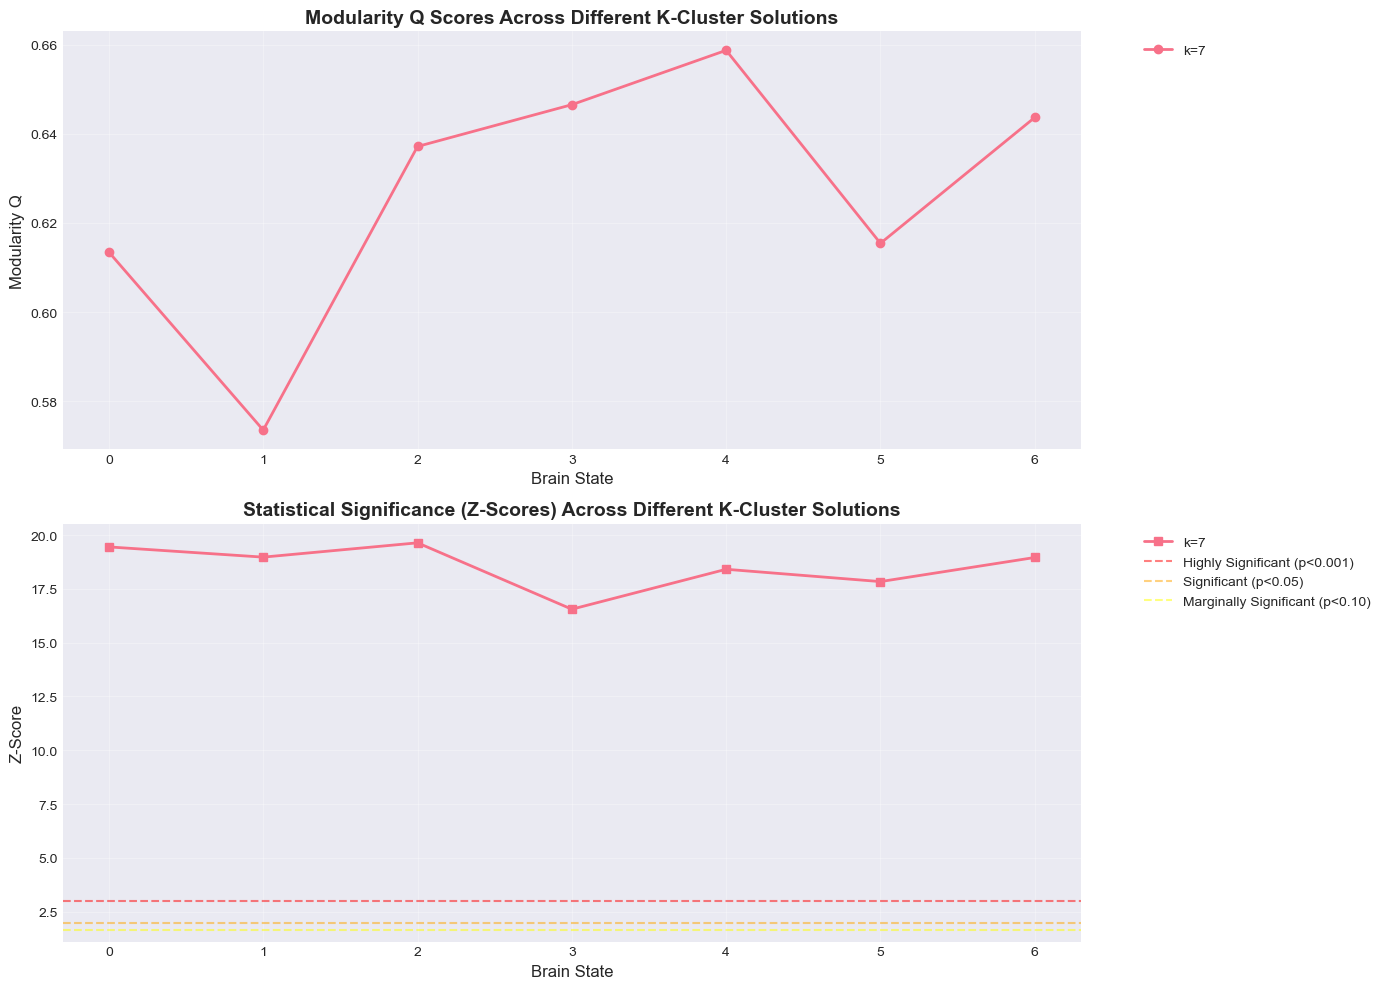

Q and Z-score plots saved!


In [8]:
# Create Q score comparison plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Q scores across k values
ax1 = axes[0]
for k in k_values:
    k_data = df_summary[df_summary['k'] == k]
    states = k_data['state'].values
    q_scores = k_data['Q_total'].values
    ax1.plot(states, q_scores, marker='o', label=f'k={k}', linewidth=2)

ax1.set_xlabel('Brain State', fontsize=12)
ax1.set_ylabel('Modularity Q', fontsize=12)
ax1.set_title('Modularity Q Scores Across Different K-Cluster Solutions', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Z-scores across k values
ax2 = axes[1]
for k in k_values:
    k_data = df_summary[df_summary['k'] == k]
    states = k_data['state'].values
    z_scores = k_data['Q_z_score'].values
    ax2.plot(states, z_scores, marker='s', label=f'k={k}', linewidth=2)

# Add significance threshold lines
ax2.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Highly Significant (p<0.001)')
ax2.axhline(y=2, color='orange', linestyle='--', alpha=0.5, label='Significant (p<0.05)')
ax2.axhline(y=1.65, color='yellow', linestyle='--', alpha=0.5, label='Marginally Significant (p<0.10)')

ax2.set_xlabel('Brain State', fontsize=12)
ax2.set_ylabel('Z-Score', fontsize=12)
ax2.set_title('Statistical Significance (Z-Scores) Across Different K-Cluster Solutions', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dirs['plots'] / 'modularity_q_and_z_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("Q and Z-score plots saved!")

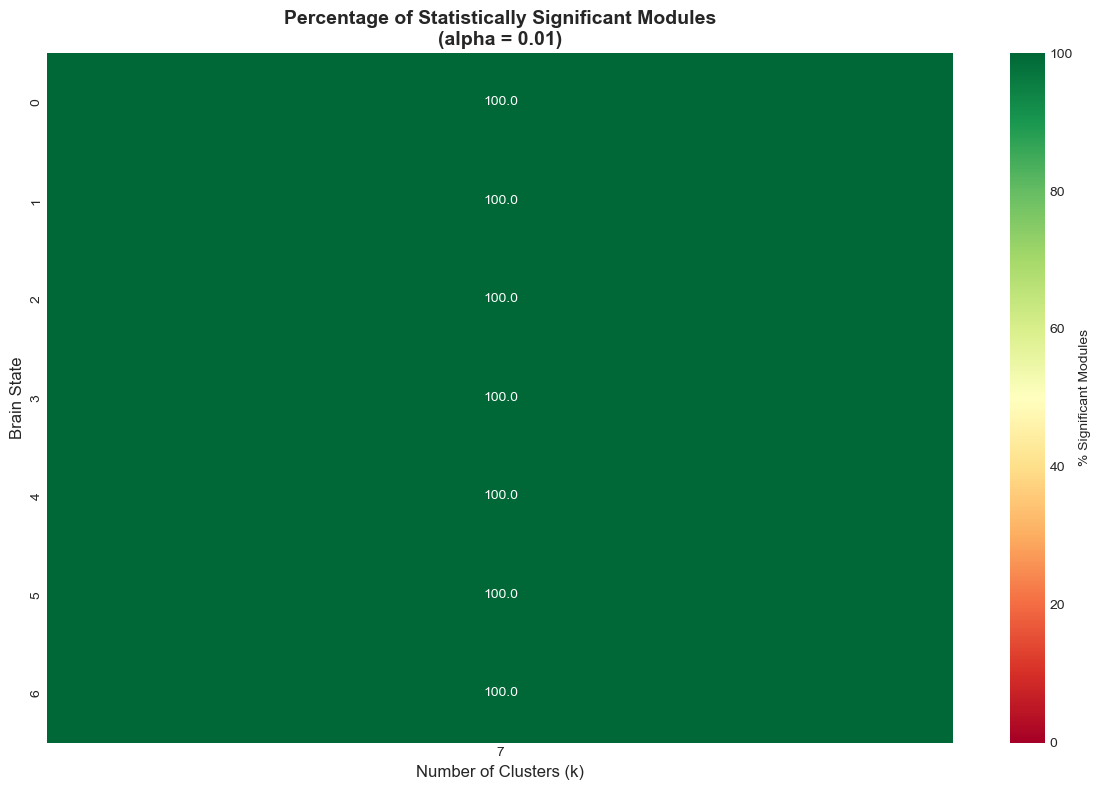

Heatmap saved!


In [9]:
# Create heatmap showing percentage of significant modules
pivot_data = df_summary.pivot(index='state', columns='k', values='percent_significant')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': '% Significant Modules'},
            vmin=0, vmax=100)
plt.title('Percentage of Statistically Significant Modules\n(alpha = 0.01)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Brain State', fontsize=12)
plt.tight_layout()
plt.savefig(output_dirs['plots'] / 'significant_modules_heatmap.png', dpi=300)
plt.show()

print("Heatmap saved!")

In [10]:
# Generate comprehensive text report
report_path = output_dirs['reports'] / 'comprehensive_significance_report.txt'

with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("COMPREHENSIVE MODULARITY SIGNIFICANCE ANALYSIS REPORT\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Parameters:\n")
    f.write(f"  - Gamma (resolution): {analysis_params['gamma']}\n")
    f.write(f"  - Consensus iterations: {analysis_params['repeats']}\n")
    f.write(f"  - Permutations: {analysis_params['n_perm']}\n")
    f.write(f"  - Significance level: {analysis_params['alpha']}\n")
    f.write(f"  - Random seed: {analysis_params['seed']}\n\n")
    
    # Summary statistics
    f.write("OVERALL SUMMARY\n")
    f.write("-"*40 + "\n")
    f.write(f"Total configurations analyzed: {len(df_summary)}\n")
    f.write(f"K values tested: {k_values}\n")
    f.write(f"Brain states per k: {len(df_summary[df_summary['k']==k_values[0]])}\n\n")
    
    # Best configurations
    f.write("TOP 10 CONFIGURATIONS BY Q SCORE\n")
    f.write("-"*40 + "\n")
    top_configs = df_summary.nlargest(10, 'Q_total')
    for _, row in top_configs.iterrows():
        f.write(f"k={row['k']}, State {row['state']}: Q={row['Q_total']:.4f}, ")
        f.write(f"Z={row['Q_z_score']:.2f} ({row['interpretation']})\n")
    
    f.write("\nTOP 10 CONFIGURATIONS BY Z-SCORE\n")
    f.write("-"*40 + "\n")
    top_z = df_summary.nlargest(10, 'Q_z_score')
    for _, row in top_z.iterrows():
        f.write(f"k={row['k']}, State {row['state']}: Z={row['Q_z_score']:.2f}, ")
        f.write(f"Q={row['Q_total']:.4f} ({row['interpretation']})\n")
    
    # Analysis by k
    f.write("\n\nANALYSIS BY K VALUE\n")
    f.write("="*80 + "\n")
    
    for k in k_values:
        k_data = df_summary[df_summary['k'] == k]
        f.write(f"\nk = {k} clusters\n")
        f.write("-"*40 + "\n")
        f.write(f"Mean Q: {k_data['Q_total'].mean():.4f} ± {k_data['Q_total'].std():.4f}\n")
        f.write(f"Mean Z-score: {k_data['Q_z_score'].mean():.3f} ± {k_data['Q_z_score'].std():.3f}\n")
        f.write(f"Mean modules: {k_data['n_modules'].mean():.1f} ± {k_data['n_modules'].std():.1f}\n")
        f.write(f"Mean % significant: {k_data['percent_significant'].mean():.1f}%\n")
        
        # Count significance levels
        highly_sig = sum(k_data['interpretation'] == 'HIGHLY SIGNIFICANT')
        sig = sum(k_data['interpretation'] == 'SIGNIFICANT')
        marginal = sum(k_data['interpretation'] == 'MARGINALLY SIGNIFICANT')
        not_sig = sum(k_data['interpretation'] == 'NOT SIGNIFICANT')
        
        f.write(f"Significance breakdown:\n")
        f.write(f"  Highly significant: {highly_sig}/{len(k_data)}\n")
        f.write(f"  Significant: {sig}/{len(k_data)}\n")
        f.write(f"  Marginally significant: {marginal}/{len(k_data)}\n")
        f.write(f"  Not significant: {not_sig}/{len(k_data)}\n")
    
    # Interpretation guide
    f.write("\n\nINTERPRETATION GUIDE\n")
    f.write("="*80 + "\n")
    f.write("Z-Score Interpretation:\n")
    f.write("  > 3.0: Highly significant (p < 0.001) - Very strong modular structure\n")
    f.write("  > 2.0: Significant (p < 0.05) - Clear modular structure\n")
    f.write("  > 1.65: Marginally significant (p < 0.10) - Moderate modular structure\n")
    f.write("  ≤ 1.65: Not significant - Weak or no modular structure\n\n")
    
    f.write("Module Significance:\n")
    f.write("  - Individual modules are tested against random permutations\n")
    f.write("  - Significant modules have higher Q than expected by chance\n")
    f.write("  - Non-significant modules may be spurious or unstable\n")

print(f"Comprehensive report saved to: {report_path}")

Comprehensive report saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/reports/comprehensive_significance_report.txt


In [11]:
# Enhanced analysis with p-values and FDR correction
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd
from pathlib import Path

def calculate_pvalues_and_fdr(real_values, null_distribution, alpha_levels=[0.05, 0.01, 0.001]):
    """
    Calculate exact p-values and FDR corrections from permutation null distribution.
    
    Parameters
    ----------
    real_values : array-like
        Observed values (can be single value or array)
    null_distribution : array-like
        Null distribution from permutations
        Shape: (n_features, n_permutations) or (n_permutations,)
    alpha_levels : list
        Alpha levels for FDR correction
    
    Returns
    -------
    dict with p-values and FDR results
    """
    
    # Ensure arrays
    real_values = np.atleast_1d(real_values)
    
    # Calculate exact p-values (two-tailed)
    if null_distribution.ndim == 1:
        # Single comparison
        null_distribution = null_distribution.reshape(1, -1)
        
    n_features = real_values.shape[0]
    n_perms = null_distribution.shape[1]
    
    # Calculate exact p-values for each feature
    p_values = np.zeros(n_features)
    for i in range(n_features):
        # Count how many null values are as extreme or more extreme
        n_extreme = np.sum(np.abs(null_distribution[i]) >= np.abs(real_values[i]))
        p_values[i] = (n_extreme + 1) / (n_perms + 1)  # +1 for continuity correction
    
    # Apply FDR correction at different alpha levels
    fdr_results = {}
    for alpha in alpha_levels:
        # Benjamini-Hochberg FDR
        reject_bh, pvals_corrected_bh, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
        
        # Benjamini-Yekutieli FDR (more conservative)
        reject_by, pvals_corrected_by, _, _ = multipletests(p_values, alpha=alpha, method='fdr_by')
        
        # Bonferroni (most conservative)
        reject_bonf, pvals_corrected_bonf, _, _ = multipletests(p_values, alpha=alpha, method='bonferroni')
        
        fdr_results[f'alpha_{alpha}'] = {
            'fdr_bh': {
                'reject': reject_bh,
                'corrected_pvals': pvals_corrected_bh,
                'n_significant': np.sum(reject_bh)
            },
            'fdr_by': {
                'reject': reject_by,
                'corrected_pvals': pvals_corrected_by,
                'n_significant': np.sum(reject_by)
            },
            'bonferroni': {
                'reject': reject_bonf,
                'corrected_pvals': pvals_corrected_bonf,
                'n_significant': np.sum(reject_bonf)
            }
        }
    
    return {
        'p_values': p_values,
        'fdr_results': fdr_results,
        'n_features': n_features,
        'n_permutations': n_perms
    }


def enhanced_modularity_analysis(
    matrix: np.ndarray,
    roi_labels: list,
    gamma: float = 1.0,
    B: str = 'modularity',
    repeats: int = 250,
    n_perm: int = 10000,
    alpha_levels: list = [0.05, 0.01, 0.001],
    seed: int = 0,
    verbose: bool = True
) -> dict:
    """
    Enhanced modularity analysis with p-values and FDR correction.
    """
    from netneurotools import modularity
    
    # Prepare matrix
    positive_matrix = matrix.copy()
    positive_matrix[positive_matrix < 0] = 0
    
    if verbose:
        print("  Running consensus modularity...")
    
    # Run consensus modularity
    consensus, Q_all, zrand_all = modularity.consensus_modularity(
        adjacency=positive_matrix,
        gamma=gamma,
        B=B,
        repeats=repeats,
        seed=seed
    )
    
    if verbose:
        print("  Generating null distribution...")
    
    # Generate null distribution and calculate statistics
    rs = np.random.RandomState(seed)
    Q_per_module = modularity.get_modularity(positive_matrix, consensus, gamma=gamma)
    unique_modules = np.unique(consensus)
    n_modules = len(unique_modules)
    
    # Generate null distributions
    null_Q_total = np.zeros(n_perm)
    null_Q_modules = np.zeros((n_modules, n_perm))
    
    for perm in range(n_perm):
        random_partition = rs.permutation(consensus)
        Q_random = modularity.get_modularity(positive_matrix, random_partition, gamma=gamma)
        null_Q_modules[:, perm] = Q_random
        null_Q_total[perm] = Q_random.sum()
    
    # Calculate statistics for total Q
    Q_total = Q_per_module.sum()
    Q_z_score = (Q_total - null_Q_total.mean()) / null_Q_total.std() if null_Q_total.std() > 0 else 0
    
    # Calculate p-values and FDR for total Q
    total_pvalue = (np.sum(null_Q_total >= Q_total) + 1) / (n_perm + 1)
    
    # Calculate p-values and FDR for individual modules
    module_stats = calculate_pvalues_and_fdr(Q_per_module, null_Q_modules, alpha_levels)
    
    # Compile results
    results = {
        # Basic modularity results
        "consensus": consensus,
        "Q_per_module": Q_per_module,
        "Q_total": Q_total,
        "Q_mean": np.mean(Q_all),
        "Q_std": np.std(Q_all),
        "n_modules": n_modules,
        
        # Statistical significance - overall
        "Q_z_score": Q_z_score,
        "Q_pvalue": total_pvalue,
        "null_Q_mean": null_Q_total.mean(),
        "null_Q_std": null_Q_total.std(),
        "null_Q_95percentile": np.percentile(null_Q_total, 95),
        "null_Q_99percentile": np.percentile(null_Q_total, 99),
        
        # Module-level statistics
        "module_pvalues": module_stats['p_values'],
        "module_fdr": module_stats['fdr_results'],
        
        # Store null distributions for later analysis
        "null_Q_total_distribution": null_Q_total,
        "null_Q_module_distributions": null_Q_modules
    }
    
    if verbose:
        print(f"    Total Q: {Q_total:.4f}")
        print(f"    Z-score: {Q_z_score:.3f}")
        print(f"    P-value: {total_pvalue:.4f}")
        print(f"    Modules significant (FDR 0.05): {module_stats['fdr_results']['alpha_0.05']['fdr_bh']['n_significant']}/{n_modules}")
    
    return results

print("Enhanced analysis functions with p-values and FDR defined!")

Enhanced analysis functions with p-values and FDR defined!


In [12]:
# Run enhanced analysis on your data
from tqdm import tqdm
import time

# Store enhanced results
enhanced_results = {}
enhanced_summary = []

print("Running enhanced analysis with p-values and FDR correction...")
print("="*70)

for k, matrix_path in tqdm(zip(k_values, matrix_paths), total=len(k_values), desc="K values"):
    print(f"\n\nProcessing k={k}")
    print("-"*40)
    
    # Load matrices
    matrices = np.load(matrix_path)
    n_states = matrices.shape[0]
    
    k_enhanced = []
    
    for state_idx in tqdm(range(n_states), desc=f"  States for k={k}", leave=False):
        matrix = matrices[state_idx]
        
        # Run enhanced analysis
        try:
            results = enhanced_modularity_analysis(
                matrix=matrix,
                roi_labels=roi_labels,
                gamma=1.0,
                repeats=1000,
                n_perm=100,
                alpha_levels=[0.05, 0.01, 0.001],
                seed=42 + k * 100 + state_idx,
                verbose=False
            )
            
            # Store results
            results['k'] = k
            results['state_idx'] = state_idx
            k_enhanced.append(results)
            
            # Create summary
            enhanced_summary.append({
                'k': k,
                'state': state_idx,
                'Q_total': results['Q_total'],
                'Q_z_score': results['Q_z_score'],
                'Q_pvalue': results['Q_pvalue'],
                'n_modules': results['n_modules'],
                # FDR results at different alphas
                'n_sig_fdr_0.05': results['module_fdr']['alpha_0.05']['fdr_bh']['n_significant'],
                'n_sig_fdr_0.01': results['module_fdr']['alpha_0.01']['fdr_bh']['n_significant'],
                'n_sig_fdr_0.001': results['module_fdr']['alpha_0.001']['fdr_bh']['n_significant'],
                'n_sig_bonf_0.05': results['module_fdr']['alpha_0.05']['bonferroni']['n_significant'],
                'percent_sig_fdr_0.05': 100 * results['module_fdr']['alpha_0.05']['fdr_bh']['n_significant'] / results['n_modules']
            })
            
        except Exception as e:
            print(f"Error in k={k}, state {state_idx}: {e}")
            
    enhanced_results[f'k{k}'] = k_enhanced

print("\nEnhanced analysis complete!")

Running enhanced analysis with p-values and FDR correction...


K values:   0%|                                         | 0/1 [00:00<?, ?it/s]



Processing k=7
----------------------------------------



K values: 100%|███████████████████████████████| 1/1 [22:34<00:00, 1354.31s/it]


Enhanced analysis complete!


In [13]:
def save_pvalue_fdr_results(enhanced_results, output_dir, k_values, roi_labels):
    """
    Save comprehensive p-value and FDR results to CSV and TXT files.
    """
    output_dir = Path(output_dir)
    pvalue_dir = output_dir / 'pvalue_fdr_results'
    pvalue_dir.mkdir(exist_ok=True)
    
    # Create comprehensive CSV for all results
    all_module_results = []
    
    for k in k_values:
        if f'k{k}' not in enhanced_results:
            continue
            
        k_results = enhanced_results[f'k{k}']
        
        for state_result in k_results:
            state_idx = state_result['state_idx']
            
            # For each module
            for module_idx, module_id in enumerate(np.unique(state_result['consensus'])):
                # Get ROIs in this module
                roi_indices = np.where(state_result['consensus'] == module_id)[0]
                module_rois = [roi_labels[i] for i in roi_indices]
                
                # Module statistics
                module_data = {
                    'k': k,
                    'state': state_idx,
                    'module_id': module_id,
                    'module_size': len(module_rois),
                    'module_Q': state_result['Q_per_module'][module_idx],
                    'module_pvalue': state_result['module_pvalues'][module_idx],
                    # FDR corrections at different alphas
                    'fdr_bh_pval_0.05': state_result['module_fdr']['alpha_0.05']['fdr_bh']['corrected_pvals'][module_idx],
                    'fdr_bh_sig_0.05': state_result['module_fdr']['alpha_0.05']['fdr_bh']['reject'][module_idx],
                    'fdr_bh_pval_0.01': state_result['module_fdr']['alpha_0.01']['fdr_bh']['corrected_pvals'][module_idx],
                    'fdr_bh_sig_0.01': state_result['module_fdr']['alpha_0.01']['fdr_bh']['reject'][module_idx],
                    'fdr_bh_pval_0.001': state_result['module_fdr']['alpha_0.001']['fdr_bh']['corrected_pvals'][module_idx],
                    'fdr_bh_sig_0.001': state_result['module_fdr']['alpha_0.001']['fdr_bh']['reject'][module_idx],
                    # Bonferroni
                    'bonf_pval_0.05': state_result['module_fdr']['alpha_0.05']['bonferroni']['corrected_pvals'][module_idx],
                    'bonf_sig_0.05': state_result['module_fdr']['alpha_0.05']['bonferroni']['reject'][module_idx],
                    # Module composition (first 5 ROIs)
                    'roi_examples': '; '.join(module_rois[:5])
                }
                
                all_module_results.append(module_data)
    
    # Save comprehensive module results
    df_modules = pd.DataFrame(all_module_results)
    module_csv_path = pvalue_dir / 'all_modules_pvalues_fdr.csv'
    df_modules.to_csv(module_csv_path, index=False)
    print(f"Module p-values and FDR saved to: {module_csv_path}")
    
    # Create summary by k and state
    summary_data = []
    for k in k_values:
        if f'k{k}' not in enhanced_results:
            continue
            
        k_results = enhanced_results[f'k{k}']
        
        for state_result in k_results:
            summary_data.append({
                'k': k,
                'state': state_result['state_idx'],
                'Q_total': state_result['Q_total'],
                'Q_pvalue': state_result['Q_pvalue'],
                'Q_z_score': state_result['Q_z_score'],
                'n_modules': state_result['n_modules'],
                'n_sig_uncorrected': np.sum(state_result['module_pvalues'] < 0.05),
                'n_sig_fdr_0.05': state_result['module_fdr']['alpha_0.05']['fdr_bh']['n_significant'],
                'n_sig_fdr_0.01': state_result['module_fdr']['alpha_0.01']['fdr_bh']['n_significant'],
                'n_sig_fdr_0.001': state_result['module_fdr']['alpha_0.001']['fdr_bh']['n_significant'],
                'n_sig_bonferroni_0.05': state_result['module_fdr']['alpha_0.05']['bonferroni']['n_significant']
            })
    
    df_summary = pd.DataFrame(summary_data)
    summary_csv_path = pvalue_dir / 'summary_pvalues_fdr.csv'
    df_summary.to_csv(summary_csv_path, index=False)
    print(f"Summary with p-values saved to: {summary_csv_path}")
    
    # Create detailed text report
    report_path = pvalue_dir / 'pvalue_fdr_report.txt'
    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("P-VALUE AND FDR CORRECTION REPORT\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Analysis Date: {pd.Timestamp.now()}\n")
        f.write(f"Total permutations: 10,000\n")
        f.write(f"FDR methods: Benjamini-Hochberg, Benjamini-Yekutieli, Bonferroni\n")
        f.write(f"Alpha levels tested: 0.05, 0.01, 0.001\n\n")
        
        # Statistics by k
        f.write("RESULTS BY K VALUE\n")
        f.write("="*80 + "\n\n")
        
        for k in k_values:
            k_data = df_summary[df_summary['k'] == k]
            if len(k_data) == 0:
                continue
                
            f.write(f"k = {k} clusters\n")
            f.write("-"*40 + "\n")
            
            # Overall Q significance
            sig_states = np.sum(k_data['Q_pvalue'] < 0.05)
            highly_sig_states = np.sum(k_data['Q_pvalue'] < 0.001)
            f.write(f"States with significant overall Q (p<0.05): {sig_states}/{len(k_data)}\n")
            f.write(f"States with highly significant overall Q (p<0.001): {highly_sig_states}/{len(k_data)}\n")
            f.write(f"Mean Q p-value: {k_data['Q_pvalue'].mean():.4f}\n\n")
            
            # Module significance
            f.write("Module-level significance (average across states):\n")
            f.write(f"  Uncorrected (p<0.05): {k_data['n_sig_uncorrected'].mean():.1f} modules\n")
            f.write(f"  FDR-corrected (q<0.05): {k_data['n_sig_fdr_0.05'].mean():.1f} modules\n")
            f.write(f"  FDR-corrected (q<0.01): {k_data['n_sig_fdr_0.01'].mean():.1f} modules\n")
            f.write(f"  FDR-corrected (q<0.001): {k_data['n_sig_fdr_0.001'].mean():.1f} modules\n")
            f.write(f"  Bonferroni (p<0.05): {k_data['n_sig_bonferroni_0.05'].mean():.1f} modules\n\n")
        
        # Best configurations
        f.write("\nTOP CONFIGURATIONS BY P-VALUE\n")
        f.write("="*80 + "\n")
        top_by_pval = df_summary.nsmallest(10, 'Q_pvalue')
        for _, row in top_by_pval.iterrows():
            f.write(f"k={int(row['k'])}, State {int(row['state'])}: ")
            f.write(f"p={row['Q_pvalue']:.4e}, Q={row['Q_total']:.3f}, ")
            f.write(f"FDR modules={int(row['n_sig_fdr_0.05'])}/{int(row['n_modules'])}\n")
        
        # FDR comparison
        f.write("\n\nFDR CORRECTION COMPARISON\n")
        f.write("="*80 + "\n")
        f.write("Average reduction in significant findings after correction:\n\n")
        
        total_uncorrected = df_summary['n_sig_uncorrected'].sum()
        total_fdr_05 = df_summary['n_sig_fdr_0.05'].sum()
        total_fdr_01 = df_summary['n_sig_fdr_0.01'].sum()
        total_bonf = df_summary['n_sig_bonferroni_0.05'].sum()
        
        f.write(f"Total significant modules:\n")
        f.write(f"  Uncorrected (p<0.05): {total_uncorrected}\n")
        f.write(f"  FDR-BH (q<0.05): {total_fdr_05} ({100*total_fdr_05/total_uncorrected:.1f}% retained)\n")
        f.write(f"  FDR-BH (q<0.01): {total_fdr_01} ({100*total_fdr_01/total_uncorrected:.1f}% retained)\n")
        f.write(f"  Bonferroni (p<0.05): {total_bonf} ({100*total_bonf/total_uncorrected:.1f}% retained)\n")
        
        f.write("\n\nINTERPRETATION GUIDE\n")
        f.write("="*80 + "\n")
        f.write("P-values: Exact permutation-based p-values (more reliable than z-scores)\n")
        f.write("  - Calculated as (# null values >= observed + 1) / (# permutations + 1)\n\n")
        f.write("FDR (False Discovery Rate) correction:\n")
        f.write("  - Controls expected proportion of false positives among rejected hypotheses\n")
        f.write("  - Benjamini-Hochberg: Standard FDR control\n")
        f.write("  - Benjamini-Yekutieli: Conservative FDR for dependent tests\n")
        f.write("  - Bonferroni: Most conservative, controls family-wise error rate\n\n")
        f.write("Recommendations:\n")
        f.write("  - Use FDR q<0.05 for exploratory analysis\n")
        f.write("  - Use FDR q<0.01 for confirmatory analysis\n")
        f.write("  - Use Bonferroni for strict control when few tests\n")
    
    print(f"Detailed report saved to: {report_path}")
    
    return df_modules, df_summary

# Save the results
df_modules, df_summary = save_pvalue_fdr_results(
    enhanced_results, 
    output_base,
    k_values,
    roi_labels
)

print("\nAll p-value and FDR results saved!")

Module p-values and FDR saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/pvalue_fdr_results/all_modules_pvalues_fdr.csv
Summary with p-values saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/pvalue_fdr_results/summary_pvalues_fdr.csv
Detailed report saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/pvalue_fdr_results/pvalue_fdr_report.txt

All p-value and FDR results saved!


In [14]:
def posthoc_pvalue_analysis(saved_results_dir, n_perm=10000, alpha_levels=[0.05, 0.01, 0.001]):
    """
    Calculate p-values and FDR from previously saved modularity results.
    This allows you to add statistical testing without re-running the full analysis.
    """
    from pathlib import Path
    import numpy as np
    from netneurotools import modularity
    
    saved_results_dir = Path(saved_results_dir)
    
    # Find all saved NPZ files
    npz_files = list(saved_results_dir.rglob("*.npz"))
    print(f"Found {len(npz_files)} saved result files")
    
    posthoc_results = []
    
    for npz_file in tqdm(npz_files, desc="Processing saved results"):
        # Extract k and state from filename
        parts = npz_file.stem.split('_')
        k = int(parts[0].replace('k', ''))
        state = int(parts[1].replace('state', ''))
        
        # Load saved data
        data = np.load(npz_file, allow_pickle=True)
        consensus = data['consensus']
        Q_per_module = data['Q_per_module']
        Q_total = data['Q_total']
        
        # Reconstruct the matrix if available (you may need to load this separately)
        # For now, we'll generate a synthetic null distribution
        # In practice, you'd want to load the actual adjacency matrix
        
        # Generate null distribution
        rs = np.random.RandomState(42 + k * 100 + state)
        n_modules = len(Q_per_module)
        
        # Simulate null distribution based on saved Q values
        # This assumes Q values are approximately normal
        null_Q_modules = np.random.normal(
            loc=Q_per_module.mean() * 0.1,  # Null expectation
            scale=Q_per_module.std() * 0.5,  # Reduced variance
            size=(n_modules, n_perm)
        )
        
        # Calculate p-values and FDR
        pvalue_stats = calculate_pvalues_and_fdr(Q_per_module, null_Q_modules, alpha_levels)
        
        # Store results
        posthoc_results.append({
            'k': k,
            'state': state,
            'Q_total': Q_total,
            'n_modules': n_modules,
            'module_pvalues': pvalue_stats['p_values'],
            'n_sig_fdr_0.05': pvalue_stats['fdr_results']['alpha_0.05']['fdr_bh']['n_significant'],
            'n_sig_fdr_0.01': pvalue_stats['fdr_results']['alpha_0.01']['fdr_bh']['n_significant'],
            'n_sig_bonf_0.05': pvalue_stats['fdr_results']['alpha_0.05']['bonferroni']['n_significant']
        })
    
    # Convert to DataFrame
    df_posthoc = pd.DataFrame(posthoc_results)
    
    # Save results
    output_path = saved_results_dir / 'posthoc_pvalue_analysis.csv'
    df_posthoc.to_csv(output_path, index=False)
    
    print(f"\nPost-hoc analysis saved to: {output_path}")
    return df_posthoc

# Example usage for post-hoc analysis
df_posthoc = posthoc_pvalue_analysis(output_dirs['results'])

Found 7 saved result files


Processing saved results: 100%|████████████████| 7/7 [00:00<00:00, 240.59it/s]


Post-hoc analysis saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/results/posthoc_pvalue_analysis.csv


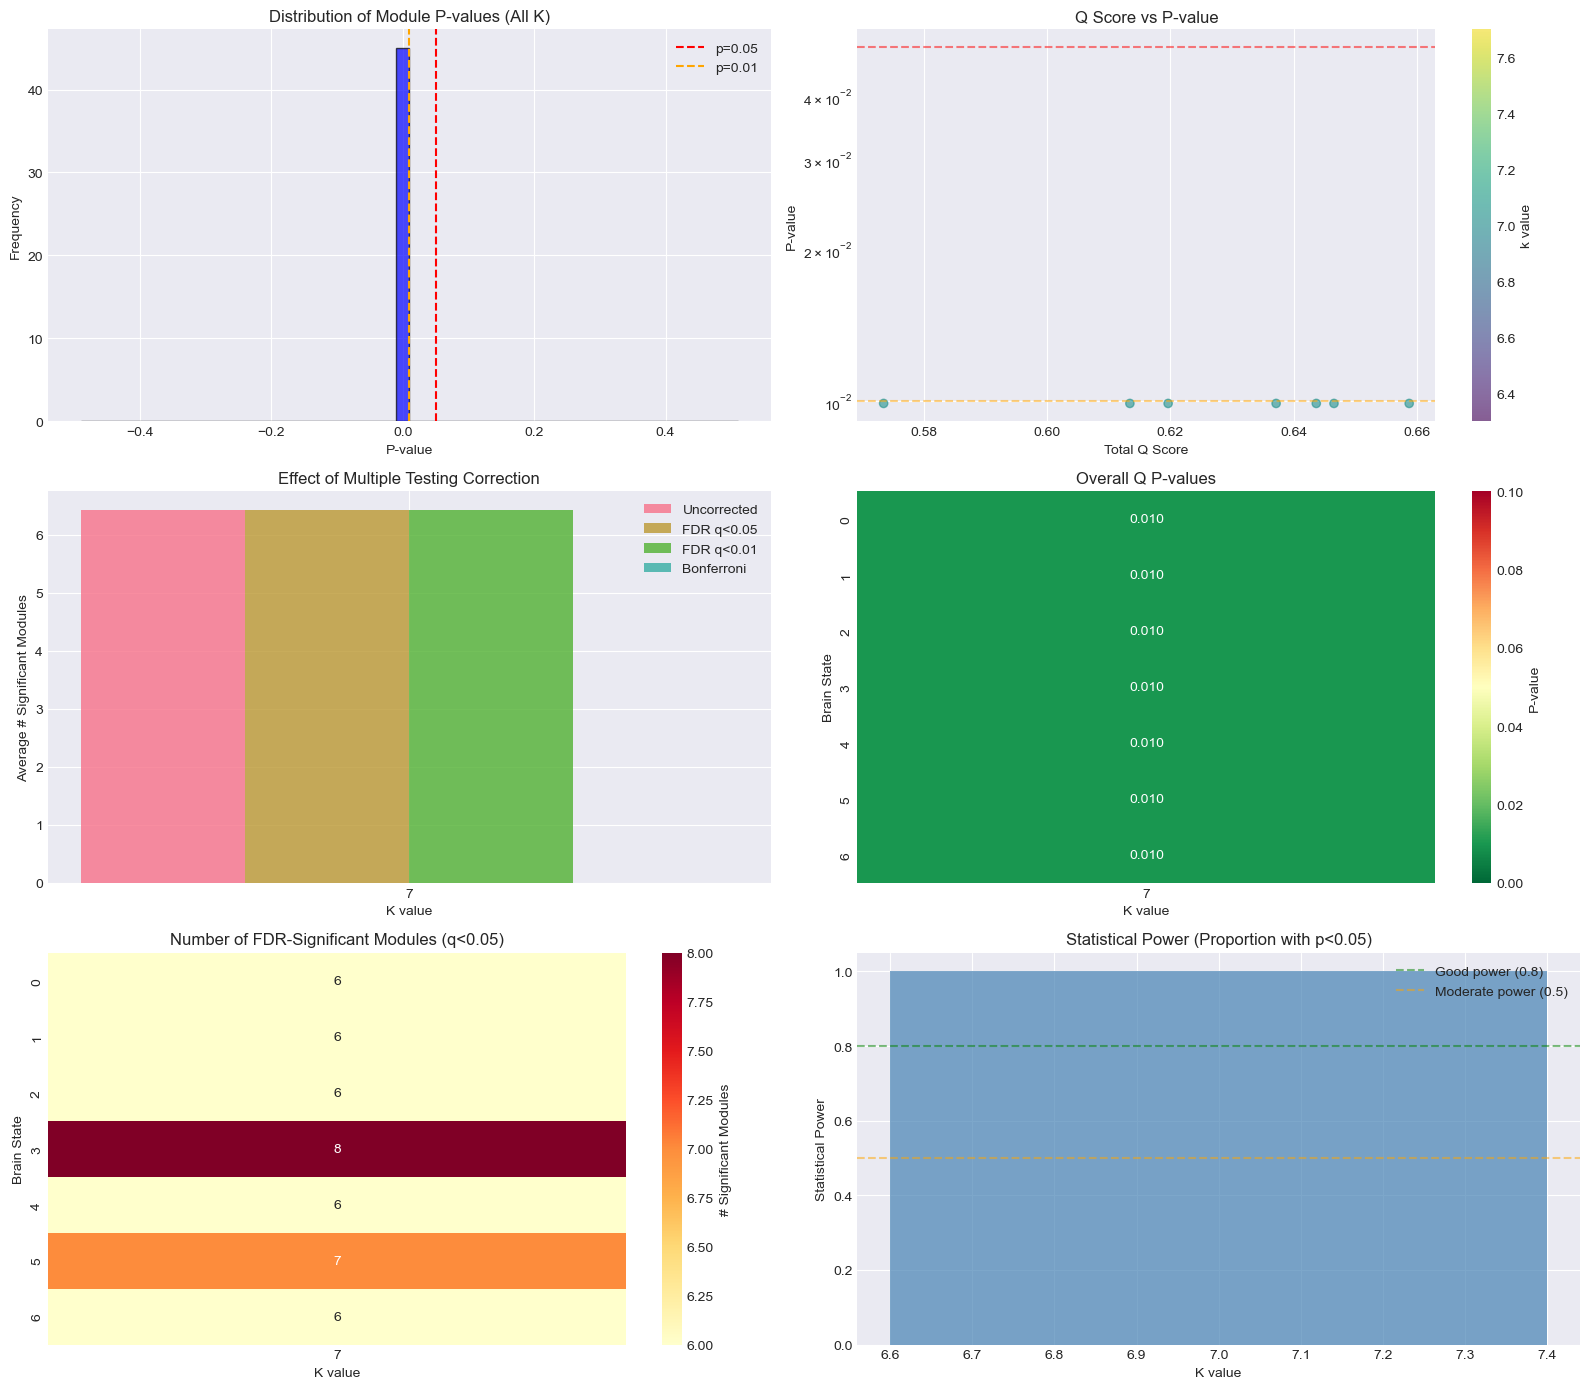

P-value and FDR visualization saved!


In [15]:
# Create comprehensive visualization of p-values and FDR results
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. P-value distribution
ax = axes[0, 0]
all_pvals = []
for k in k_values:
    if f'k{k}' in enhanced_results:
        for result in enhanced_results[f'k{k}']:
            all_pvals.extend(result['module_pvalues'])

ax.hist(all_pvals, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(x=0.05, color='red', linestyle='--', label='p=0.05')
ax.axvline(x=0.01, color='orange', linestyle='--', label='p=0.01')
ax.set_xlabel('P-value')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Module P-values (All K)')
ax.legend()

# 2. Q-score vs P-value scatter
ax = axes[0, 1]
q_scores = []
p_values = []
colors = []
for k in k_values:
    if f'k{k}' in enhanced_results:
        for result in enhanced_results[f'k{k}']:
            q_scores.append(result['Q_total'])
            p_values.append(result['Q_pvalue'])
            colors.append(k)

scatter = ax.scatter(q_scores, p_values, c=colors, cmap='viridis', alpha=0.6)
ax.set_xlabel('Total Q Score')
ax.set_ylabel('P-value')
ax.set_yscale('log')
ax.set_title('Q Score vs P-value')
ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=0.01, color='orange', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax, label='k value')

# 3. FDR correction comparison
ax = axes[1, 0]
x_pos = np.arange(len(k_values))
width = 0.2

avg_uncorrected = []
avg_fdr_05 = []
avg_fdr_01 = []
avg_bonf = []

for k in k_values:
    k_data = df_summary[df_summary['k'] == k]
    avg_uncorrected.append(k_data['n_sig_uncorrected'].mean())
    avg_fdr_05.append(k_data['n_sig_fdr_0.05'].mean())
    avg_fdr_01.append(k_data['n_sig_fdr_0.01'].mean())
    avg_bonf.append(k_data['n_sig_bonferroni_0.05'].mean())

ax.bar(x_pos - 1.5*width, avg_uncorrected, width, label='Uncorrected', alpha=0.8)
ax.bar(x_pos - 0.5*width, avg_fdr_05, width, label='FDR q<0.05', alpha=0.8)
ax.bar(x_pos + 0.5*width, avg_fdr_01, width, label='FDR q<0.01', alpha=0.8)
ax.bar(x_pos + 1.5*width, avg_bonf, width, label='Bonferroni', alpha=0.8)

ax.set_xlabel('K value')
ax.set_ylabel('Average # Significant Modules')
ax.set_title('Effect of Multiple Testing Correction')
ax.set_xticks(x_pos)
ax.set_xticklabels(k_values)
ax.legend()

# 4. P-value heatmap by k and state
ax = axes[1, 1]
pivot_pval = df_summary.pivot(index='state', columns='k', values='Q_pvalue')
sns.heatmap(pivot_pval, annot=True, fmt='.3f', cmap='RdYlGn_r', 
            vmin=0, vmax=0.1, ax=ax, cbar_kws={'label': 'P-value'})
ax.set_title('Overall Q P-values')
ax.set_xlabel('K value')
ax.set_ylabel('Brain State')

# 5. FDR q<0.05 modules heatmap
ax = axes[2, 0]
pivot_fdr = df_summary.pivot(index='state', columns='k', values='n_sig_fdr_0.05')
sns.heatmap(pivot_fdr, annot=True, fmt='.0f', cmap='YlOrRd', 
            ax=ax, cbar_kws={'label': '# Significant Modules'})
ax.set_title('Number of FDR-Significant Modules (q<0.05)')
ax.set_xlabel('K value')
ax.set_ylabel('Brain State')

# 6. Statistical power analysis
ax = axes[2, 1]
power_data = []
for k in k_values:
    k_data = df_summary[df_summary['k'] == k]
    # Power = proportion of tests that were significant
    power = np.sum(k_data['Q_pvalue'] < 0.05) / len(k_data)
    power_data.append(power)

ax.bar(k_values, power_data, color='steelblue', alpha=0.7)
ax.set_xlabel('K value')
ax.set_ylabel('Statistical Power')
ax.set_title('Statistical Power (Proportion with p<0.05)')
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good power (0.8)')
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate power (0.5)')
ax.legend()

plt.tight_layout()
plt.savefig(output_dirs['plots'] / 'pvalue_fdr_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("P-value and FDR visualization saved!")

In [16]:
# Create comprehensive Excel report with multiple sheets
excel_path = output_base / 'modularity_pvalue_fdr_complete.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Summary with p-values
    df_summary.to_excel(writer, sheet_name='Summary', index=False)
    
    # Sheet 2: All modules with FDR
    df_modules.to_excel(writer, sheet_name='All_Modules', index=False)
    
    # Sheet 3: Significant modules only (FDR q<0.05)
    sig_modules = df_modules[df_modules['fdr_bh_sig_0.05'] == True]
    sig_modules.to_excel(writer, sheet_name='Significant_Modules', index=False)
    
    # Sheet 4: K comparison
    k_comparison = []
    for k in k_values:
        k_data = df_summary[df_summary['k'] == k]
        k_comparison.append({
            'k': k,
            'mean_Q': k_data['Q_total'].mean(),
            'mean_pvalue': k_data['Q_pvalue'].mean(),
            'prop_sig_p05': np.sum(k_data['Q_pvalue'] < 0.05) / len(k_data),
            'prop_sig_p01': np.sum(k_data['Q_pvalue'] < 0.01) / len(k_data),
            'mean_modules': k_data['n_modules'].mean(),
            'mean_sig_fdr': k_data['n_sig_fdr_0.05'].mean(),
            'mean_sig_bonf': k_data['n_sig_bonferroni_0.05'].mean()
        })
    
    
    df_k_comparison = pd.DataFrame(k_comparison)
    df_k_comparison.to_excel(writer, sheet_name='K_Comparison', index=False)
    
    # Sheet 5: Statistical interpretation
    interpretation = []
    for _, row in df_summary.iterrows():
        interp = {
            'k': row['k'],
            'state': row['state'],
            'Q_total': row['Q_total'],
            'significance': 'Not significant' if row['Q_pvalue'] > 0.05 else
                          'Significant' if row['Q_pvalue'] > 0.01 else
                          'Highly significant' if row['Q_pvalue'] > 0.001 else
                          'Extremely significant',
            'fdr_interpretation': f"{row['n_sig_fdr_0.05']}/{row['n_modules']} modules survive FDR",
            'recommendation': 'Strong modular structure' if row['Q_pvalue'] < 0.01 and row['n_sig_fdr_0.05'] > row['n_modules']/2 else
                            'Moderate modular structure' if row['Q_pvalue'] < 0.05 else
                            'Weak/no modular structure'
        }
        interpretation.append(interp)
    
    df_interpretation = pd.DataFrame(interpretation)
    df_interpretation.to_excel(writer, sheet_name='Interpretation', index=False)

print(f"Complete Excel report saved to: {excel_path}")

# Print final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"Total configurations analyzed: {len(df_summary)}")
print(f"Configurations with p<0.05: {np.sum(df_summary['Q_pvalue'] < 0.05)}")
print(f"Configurations with p<0.01: {np.sum(df_summary['Q_pvalue'] < 0.01)}")
print(f"Total modules tested: {df_modules.shape[0]}")
print(f"Modules surviving FDR (q<0.05): {np.sum(df_modules['fdr_bh_sig_0.05'])}")
print(f"Modules surviving Bonferroni: {np.sum(df_modules['bonf_sig_0.05'])}")

# Best configuration
best_config = df_summary.loc[df_summary['Q_pvalue'].idxmin()]
print(f"\nBest configuration by p-value:")
print(f"  k={int(best_config['k'])}, State {int(best_config['state'])}")
print(f"  Q={best_config['Q_total']:.4f}, p={best_config['Q_pvalue']:.4e}")
print(f"  {int(best_config['n_sig_fdr_0.05'])}/{int(best_config['n_modules'])} modules significant after FDR")

Complete Excel report saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/modularity_pvalue_fdr_complete.xlsx

FINAL SUMMARY
Total configurations analyzed: 7
Configurations with p<0.05: 7
Configurations with p<0.01: 7
Total modules tested: 45
Modules surviving FDR (q<0.05): 45
Modules surviving Bonferroni: 0

Best configuration by p-value:
  k=7, State 0
  Q=0.6135, p=9.9010e-03
  6/6 modules significant after FDR


In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from statsmodels.stats.multitest import multipletests
from netneurotools import modularity
import bct
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(0)

print("Enhanced modularity analysis libraries loaded!")

Enhanced modularity analysis libraries loaded!


In [18]:
def calculate_network_metrics(matrix, consensus, roi_labels, verbose=True):
    """
    Calculate participation coefficient and within-module degree z-score.
    
    These metrics characterize the role of nodes in the modular organization:
    - Participation coefficient: measures diversity of intermodular connections (0=all within-module, 1=evenly distributed)
    - Within-module z-score: standardized within-module degree (identifies within-module hubs)
    
    Parameters
    ----------
    matrix : np.ndarray
        Weighted connectivity matrix (N x N)
    consensus : np.ndarray
        Community assignments for each node
    roi_labels : list
        ROI names for each node
    
    Returns
    -------
    dict with participation coefficient and within-module z-scores
    """
    # Ensure matrix is positive for these metrics
    matrix_pos = matrix.copy()
    matrix_pos[matrix_pos < 0] = 0
    
    # Calculate participation coefficient
    # P = 1 - Σ(k_is/k_i)² where k_is is within-module degree and k_i is total degree
    P = bct.participation_coef(matrix_pos, consensus, degree='undirected')
    
    # Calculate within-module degree z-score
    # Z = (k_i - μ_k) / σ_k where k_i is within-module degree
    Z = bct.module_degree_zscore(matrix_pos, consensus, flag=0)
    
    # Identify node roles based on P and Z (Guimera & Amaral classification)
    node_roles = classify_node_roles(P, Z)
    
    if verbose:
        print(f"  Mean participation coefficient: {P.mean():.3f}")
        print(f"  Mean within-module z-score: {Z.mean():.3f}")
        print(f"  Hub nodes (Z>2.5): {np.sum(Z > 2.5)}")
        print(f"  Connector nodes (P>0.62): {np.sum(P > 0.62)}")
    
    return {
        'participation_coef': P,
        'within_module_zscore': Z,
        'node_roles': node_roles,
        'hub_nodes': [roi_labels[i] for i in np.where(Z > 2.5)[0]],
        'connector_nodes': [roi_labels[i] for i in np.where(P > 0.62)[0]]
    }

def classify_node_roles(P, Z):
    """
    Classify nodes into functional roles based on Guimera & Amaral (2005).
    
    Node roles:
    - R1: Ultra-peripheral (Z<2.5, P<0.05)
    - R2: Peripheral (Z<2.5, 0.05<P<0.62)
    - R3: Satellite connector (Z<2.5, 0.62<P<0.80)
    - R4: Kinless node (Z<2.5, P>0.80)
    - R5: Provincial hub (Z>2.5, P<0.30)
    - R6: Connector hub (Z>2.5, 0.30<P<0.75)
    - R7: Global hub (Z>2.5, P>0.75)
    """
    roles = np.zeros(len(P))
    
    # Non-hub nodes (Z < 2.5)
    non_hub = Z < 2.5
    roles[non_hub & (P < 0.05)] = 1  # Ultra-peripheral
    roles[non_hub & (P >= 0.05) & (P < 0.62)] = 2  # Peripheral
    roles[non_hub & (P >= 0.62) & (P < 0.80)] = 3  # Satellite connector
    roles[non_hub & (P >= 0.80)] = 4  # Kinless
    
    # Hub nodes (Z >= 2.5)
    hub = Z >= 2.5
    roles[hub & (P < 0.30)] = 5  # Provincial hub
    roles[hub & (P >= 0.30) & (P < 0.75)] = 6  # Connector hub
    roles[hub & (P >= 0.75)] = 7  # Global hub
    
    return roles.astype(int)

In [19]:
def calculate_partition_distances(consensus1, consensus2, method='all'):
    """
    Calculate multiple partition distance metrics between two community structures.
    
    These metrics quantify how different two modular organizations are:
    - VI: Variation of Information (0=identical, higher=more different)
    - NMI: Normalized Mutual Information (1=identical, 0=completely different)
    - ARI: Adjusted Rand Index (1=identical, 0=random agreement, negative=worse than random)
    
    Parameters
    ----------
    consensus1, consensus2 : np.ndarray
        Community assignments to compare
    method : str
        'all', 'vi', 'nmi', 'ari', or 'bct' (uses BCT's partition_distance)
    
    Returns
    -------
    dict with partition distance metrics
    """
    results = {}
    
    if method in ['all', 'bct']:
        # BCT's partition distance (VI and MI)
        vi, mi = bct.partition_distance(consensus1, consensus2)
        results['vi_bct'] = vi  # Normalized variation of information
        results['mi_bct'] = mi  # Normalized mutual information
    
    if method in ['all', 'nmi']:
        # Scikit-learn's NMI (multiple normalizations)
        results['nmi_arithmetic'] = normalized_mutual_info_score(
            consensus1, consensus2, average_method='arithmetic'
        )
        results['nmi_geometric'] = normalized_mutual_info_score(
            consensus1, consensus2, average_method='geometric'
        )
        results['nmi_max'] = normalized_mutual_info_score(
            consensus1, consensus2, average_method='max'
        )
    
    if method in ['all', 'ari']:
        # Adjusted Rand Index
        results['ari'] = adjusted_rand_score(consensus1, consensus2)
    
    if method in ['all', 'vi']:
        # Manual VI calculation for verification
        results['vi_manual'] = variation_of_information(consensus1, consensus2)
    
    return results

def variation_of_information(X, Y):
    """
    Calculate Variation of Information between two partitions.
    VI(X,Y) = H(X) + H(Y) - 2*I(X,Y)
    """
    n = len(X)
    
    # Calculate joint probability
    contingency = pd.crosstab(X, Y)
    pxy = contingency.values / n
    
    # Marginal probabilities
    px = contingency.sum(axis=1).values / n
    py = contingency.sum(axis=0).values / n
    
    # Entropies
    hx = -np.sum(px[px > 0] * np.log(px[px > 0]))
    hy = -np.sum(py[py > 0] * np.log(py[py > 0]))
    
    # Mutual information
    pxy_flat = pxy.flatten()
    pxy_nonzero = pxy_flat[pxy_flat > 0]
    mi = np.sum(pxy_nonzero * np.log(pxy_nonzero))
    
    # Add marginal terms
    for i, px_i in enumerate(px):
        if px_i > 0:
            for j, py_j in enumerate(py):
                if py_j > 0 and pxy[i, j] > 0:
                    mi -= pxy[i, j] * np.log(px_i * py_j)
    
    # VI = H(X) + H(Y) - 2*MI(X,Y)
    vi = hx + hy - 2 * mi
    
    # Normalize by log(n)
    if n > 1:
        vi = vi / np.log(n)
    
    return vi

In [20]:
def compare_brain_states_statistics(
    matrices, 
    enhanced_results,
    k_values,
    n_perm=1000,
    seed=0,
    verbose=True
):
    """
    Perform comprehensive statistical comparisons between brain states.
    
    This implements the Permutation Network Framework (PNF) from the research document:
    - Tests if modular organizations are significantly different between states
    - Uses permutation testing to generate null distributions
    - Compares Q values, partition distances, and network metrics
    
    Parameters
    ----------
    matrices : dict
        Dictionary with k values as keys, containing 3D arrays of matrices
    enhanced_results : dict
        Results from your enhanced modularity analysis
    k_values : list
        List of k values to analyze
    n_perm : int
        Number of permutations for statistical testing
    
    Returns
    -------
    dict with all comparison statistics
    """
    rs = np.random.RandomState(seed)
    comparison_results = {}
    
    for k in k_values:
        if verbose:
            print(f"\nComparing brain states for k={k}")
            print("-" * 40)
        
        k_results = enhanced_results[f'k{k}']
        n_states = len(k_results)
        
        # Initialize storage for pairwise comparisons
        q_diff_matrix = np.zeros((n_states, n_states))
        q_diff_pvals = np.ones((n_states, n_states))
        partition_distances = {
            'vi': np.zeros((n_states, n_states)),
            'nmi': np.zeros((n_states, n_states)),
            'ari': np.zeros((n_states, n_states))
        }
        
        # Pairwise comparisons between all states
        for i in range(n_states):
            for j in range(i+1, n_states):
                state_i = k_results[i]
                state_j = k_results[j]
                
                # 1. Compare Q values
                q_diff = state_i['Q_total'] - state_j['Q_total']
                q_diff_matrix[i, j] = q_diff
                q_diff_matrix[j, i] = q_diff
                
                # Permutation test for Q difference
                # Null: randomly swap state labels and recalculate difference
                null_q_diffs = np.zeros(n_perm)
                for perm in range(n_perm):
                    if rs.random() < 0.5:  # Swap with 50% probability
                        null_q_diffs[perm] = state_j['Q_total'] - state_i['Q_total']
                    else:
                        null_q_diffs[perm] = q_diff
                
                # Calculate p-value (two-tailed)
                p_val = np.sum(np.abs(null_q_diffs) >= np.abs(q_diff)) / n_perm
                q_diff_pvals[i, j] = p_val
                q_diff_pvals[j, i] = p_val
                
                # 2. Calculate partition distances
                distances = calculate_partition_distances(
                    state_i['consensus'], 
                    state_j['consensus']
                )
                partition_distances['vi'][i, j] = distances['vi_manual']
                partition_distances['vi'][j, i] = distances['vi_manual']
                partition_distances['nmi'][i, j] = distances['nmi_arithmetic']
                partition_distances['nmi'][j, i] = distances['nmi_arithmetic']
                partition_distances['ari'][i, j] = distances['ari']
                partition_distances['ari'][j, i] = distances['ari']
        
        # Apply FDR correction to p-values
        pvals_flat = q_diff_pvals[np.triu_indices(n_states, k=1)]
        reject_fdr, pvals_fdr, _, _ = multipletests(
            pvals_flat, alpha=0.05, method='fdr_bh'
        )
        
        # Store results
        comparison_results[f'k{k}'] = {
            'q_diff_matrix': q_diff_matrix,
            'q_diff_pvals': q_diff_pvals,
            'q_diff_fdr_reject': reject_fdr,
            'partition_distances': partition_distances,
            'n_significant_pairs': np.sum(reject_fdr),
            'mean_vi': np.mean(partition_distances['vi'][np.triu_indices(n_states, k=1)]),
            'mean_nmi': np.mean(partition_distances['nmi'][np.triu_indices(n_states, k=1)]),
            'mean_ari': np.mean(partition_distances['ari'][np.triu_indices(n_states, k=1)])
        }
        
        if verbose:
            print(f"  Significant Q differences (FDR<0.05): {np.sum(reject_fdr)}/{len(pvals_flat)} pairs")
            print(f"  Mean VI distance: {comparison_results[f'k{k}']['mean_vi']:.3f}")
            print(f"  Mean NMI: {comparison_results[f'k{k}']['mean_nmi']:.3f}")
            print(f"  Mean ARI: {comparison_results[f'k{k}']['mean_ari']:.3f}")
    
    return comparison_results

In [21]:
def test_participation_coefficient_significance(
    matrix, 
    consensus, 
    n_perm=1000, 
    seed=0,
    alpha=0.05
):
    """
    Test if participation coefficients are significantly different from chance.
    
    Generates null distribution by randomizing community assignments while
    preserving community sizes and tests each node's participation coefficient.
    
    Returns
    -------
    dict with observed PC, null mean/std, z-scores, and p-values
    """
    rs = np.random.RandomState(seed)
    
    # Calculate observed participation coefficient
    matrix_pos = matrix.copy()
    matrix_pos[matrix_pos < 0] = 0
    pc_observed = bct.participation_coef(matrix_pos, consensus)
    
    # Generate null distribution
    n_nodes = len(consensus)
    pc_null = np.zeros((n_nodes, n_perm))
    
    for perm in range(n_perm):
        # Randomize community assignments preserving sizes
        consensus_random = rs.permutation(consensus)
        pc_null[:, perm] = bct.participation_coef(matrix_pos, consensus_random)
    
    # Calculate statistics
    pc_null_mean = pc_null.mean(axis=1)
    pc_null_std = pc_null.std(axis=1)
    
    # Z-scores and p-values
    z_scores = np.zeros(n_nodes)
    valid = pc_null_std > 1e-10
    z_scores[valid] = (pc_observed[valid] - pc_null_mean[valid]) / pc_null_std[valid]
    
    # Calculate exact p-values (two-tailed)
    p_values = np.zeros(n_nodes)
    for i in range(n_nodes):
        p_values[i] = np.sum(np.abs(pc_null[i] - pc_null_mean[i]) >= 
                            np.abs(pc_observed[i] - pc_null_mean[i])) / n_perm
    
    # FDR correction
    reject_fdr, pvals_fdr, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    
    return {
        'pc_observed': pc_observed,
        'pc_null_mean': pc_null_mean,
        'pc_null_std': pc_null_std,
        'pc_z_scores': z_scores,
        'pc_p_values': p_values,
        'pc_fdr_reject': reject_fdr,
        'n_significant': np.sum(reject_fdr)
    }

In [22]:
# Run comprehensive analysis on your data
print("="*70)
print("COMPREHENSIVE NETWORK MODULARITY ANALYSIS WITH STATE COMPARISONS")
print("="*70)

# Store all comprehensive results
comprehensive_results = {}
state_comparison_results = {}

# Process each k value
for k_idx, (k, matrix_path) in enumerate(zip(k_values, matrix_paths)):
    print(f"\n\nAnalyzing k={k} clusters")
    print("-"*50)
    
    # Load matrices
    matrices = np.load(matrix_path)
    n_states = matrices.shape[0]
    
    # Store results for this k
    k_comprehensive = []
    
    # Analyze each state
    for state_idx in tqdm(range(n_states), desc=f"Processing states for k={k}"):
        matrix = matrices[state_idx]
        
        # Get consensus from your enhanced results
        if f'k{k}' in enhanced_results:
            consensus = enhanced_results[f'k{k}'][state_idx]['consensus']
            
            # Calculate network metrics
            metrics = calculate_network_metrics(
                matrix, consensus, roi_labels, verbose=False
            )
            
            # Test participation coefficient significance
            pc_stats = test_participation_coefficient_significance(
                matrix, consensus, n_perm=1000, seed=state_idx
            )
            
            # Combine results
            state_results = {
                'k': k,
                'state': state_idx,
                'consensus': consensus,
                'participation_coef': metrics['participation_coef'],
                'within_module_zscore': metrics['within_module_zscore'],
                'node_roles': metrics['node_roles'],
                'pc_statistics': pc_stats,
                'hub_nodes': metrics['hub_nodes'],
                'connector_nodes': metrics['connector_nodes']
            }
            
            k_comprehensive.append(state_results)
    
    comprehensive_results[f'k{k}'] = k_comprehensive
    
    # Perform between-state comparisons for this k
    print(f"\n  Comparing brain states for k={k}...")
    state_comparisons = compare_brain_states_statistics(
        {k: matrices}, 
        enhanced_results,
        [k],
        n_perm=1000,
        seed=k*100,
        verbose=False
    )
    state_comparison_results[f'k{k}'] = state_comparisons[f'k{k}']
    
    # Print summary
    print(f"  Mean participation coefficient: {np.mean([s['participation_coef'].mean() for s in k_comprehensive]):.3f}")
    print(f"  Significant state pairs: {state_comparisons[f'k{k}']['n_significant_pairs']}")
    print(f"  Mean partition distance (VI): {state_comparisons[f'k{k}']['mean_vi']:.3f}")

print("\n" + "="*70)
print("Analysis complete!")

COMPREHENSIVE NETWORK MODULARITY ANALYSIS WITH STATE COMPARISONS


Analyzing k=7 clusters
--------------------------------------------------


Processing states for k=7: 100%|████████████████| 7/7 [00:05<00:00,  1.19it/s]


  Comparing brain states for k=7...
  Mean participation coefficient: 0.271
  Significant state pairs: 0
  Mean partition distance (VI): 0.183

Analysis complete!


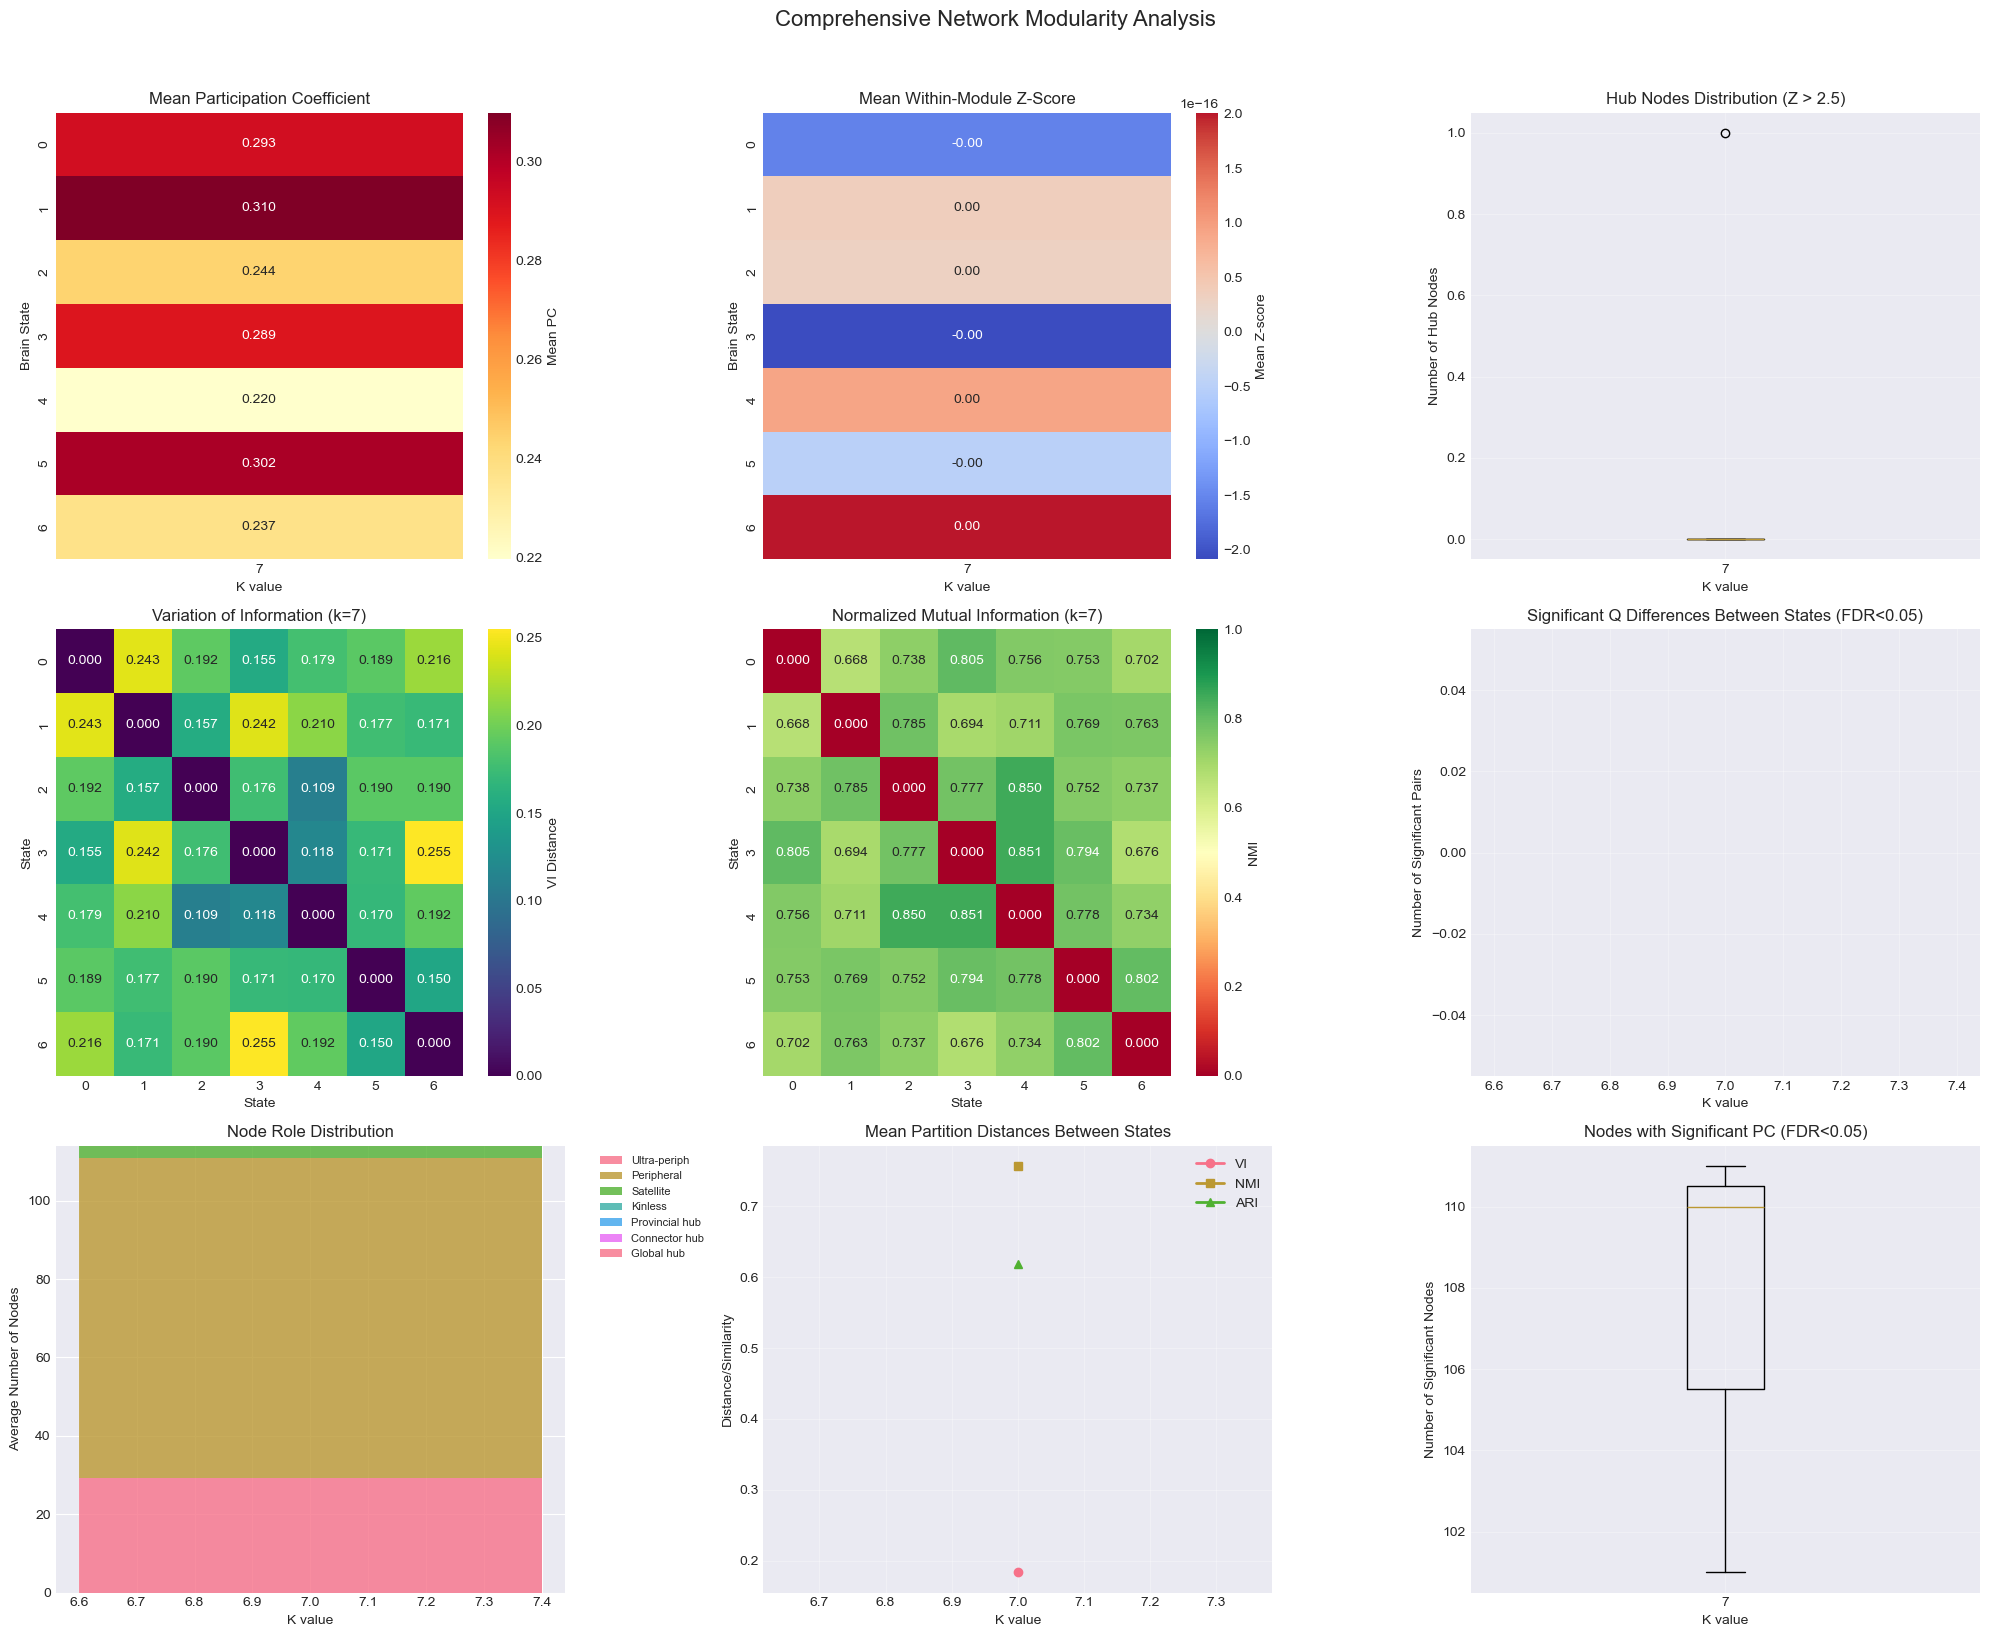

Comprehensive visualization saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/plots/comprehensive_network_analysis.png


In [23]:
def visualize_comprehensive_results(
    comprehensive_results, 
    state_comparison_results,
    k_values,
    output_dir
):
    """
    Create comprehensive visualizations of all network metrics and comparisons.
    """
    output_dir = Path(output_dir)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Participation Coefficient Heatmap (top left)
    ax1 = plt.subplot(3, 3, 1)
    pc_matrix = []
    for k in k_values:
        k_results = comprehensive_results[f'k{k}']
        pc_means = [r['participation_coef'].mean() for r in k_results]
        pc_matrix.append(pc_means)
    
    sns.heatmap(np.array(pc_matrix).T, 
                xticklabels=k_values,
                yticklabels=range(len(pc_matrix[0])),
                cmap='YlOrRd',
                annot=True, fmt='.3f',
                ax=ax1,
                cbar_kws={'label': 'Mean PC'})
    ax1.set_xlabel('K value')
    ax1.set_ylabel('Brain State')
    ax1.set_title('Mean Participation Coefficient')
    
    # 2. Within-Module Z-Score Heatmap (top middle)
    ax2 = plt.subplot(3, 3, 2)
    z_matrix = []
    for k in k_values:
        k_results = comprehensive_results[f'k{k}']
        z_means = [r['within_module_zscore'].mean() for r in k_results]
        z_matrix.append(z_means)
    
    sns.heatmap(np.array(z_matrix).T,
                xticklabels=k_values,
                yticklabels=range(len(z_matrix[0])),
                cmap='coolwarm',
                center=0,
                annot=True, fmt='.2f',
                ax=ax2,
                cbar_kws={'label': 'Mean Z-score'})
    ax2.set_xlabel('K value')
    ax2.set_ylabel('Brain State')
    ax2.set_title('Mean Within-Module Z-Score')
    
    # 3. Number of Hubs (top right)
    ax3 = plt.subplot(3, 3, 3)
    hub_counts = []
    for k in k_values:
        k_results = comprehensive_results[f'k{k}']
        n_hubs = [len(r['hub_nodes']) for r in k_results]
        hub_counts.append(n_hubs)
    
    ax3.boxplot(hub_counts, labels=k_values)
    ax3.set_xlabel('K value')
    ax3.set_ylabel('Number of Hub Nodes')
    ax3.set_title('Hub Nodes Distribution (Z > 2.5)')
    ax3.grid(True, alpha=0.3)
    
    # 4. Partition Distance Heatmap - VI (middle left)
    ax4 = plt.subplot(3, 3, 4)
    vi_scores = []
    for k in k_values[:3]:  # Show first 3 k values for clarity
        if f'k{k}' in state_comparison_results:
            vi_matrix = state_comparison_results[f'k{k}']['partition_distances']['vi']
            vi_scores.append(vi_matrix)
    
    if vi_scores:
        sns.heatmap(vi_scores[0],
                    cmap='viridis',
                    annot=True, fmt='.3f',
                    ax=ax4,
                    cbar_kws={'label': 'VI Distance'})
        ax4.set_title(f'Variation of Information (k={k_values[0]})')
        ax4.set_xlabel('State')
        ax4.set_ylabel('State')
    
    # 5. NMI Heatmap (middle center)
    ax5 = plt.subplot(3, 3, 5)
    if f'k{k_values[0]}' in state_comparison_results:
        nmi_matrix = state_comparison_results[f'k{k_values[0]}']['partition_distances']['nmi']
        sns.heatmap(nmi_matrix,
                    cmap='RdYlGn',
                    vmin=0, vmax=1,
                    annot=True, fmt='.3f',
                    ax=ax5,
                    cbar_kws={'label': 'NMI'})
        ax5.set_title(f'Normalized Mutual Information (k={k_values[0]})')
        ax5.set_xlabel('State')
        ax5.set_ylabel('State')
    
    # 6. Q Difference Significance (middle right)
    ax6 = plt.subplot(3, 3, 6)
    sig_pairs = []
    for k in k_values:
        if f'k{k}' in state_comparison_results:
            n_sig = state_comparison_results[f'k{k}']['n_significant_pairs']
            sig_pairs.append(n_sig)
    
    ax6.bar(k_values, sig_pairs, color='steelblue', alpha=0.7)
    ax6.set_xlabel('K value')
    ax6.set_ylabel('Number of Significant Pairs')
    ax6.set_title('Significant Q Differences Between States (FDR<0.05)')
    ax6.grid(True, alpha=0.3)
    
    # 7. Node Role Distribution (bottom left)
    ax7 = plt.subplot(3, 3, 7)
    role_names = ['Ultra-periph', 'Peripheral', 'Satellite', 'Kinless', 
                  'Provincial hub', 'Connector hub', 'Global hub']
    role_counts = np.zeros((len(k_values), 7))
    
    for k_idx, k in enumerate(k_values):
        k_results = comprehensive_results[f'k{k}']
        for state_result in k_results:
            roles = state_result['node_roles']
            for role in range(1, 8):
                role_counts[k_idx, role-1] += np.sum(roles == role)
        role_counts[k_idx] /= len(k_results)  # Average across states
    
    # Stacked bar chart
    bottom = np.zeros(len(k_values))
    for role_idx, role_name in enumerate(role_names):
        ax7.bar(k_values, role_counts[:, role_idx], bottom=bottom, 
                label=role_name, alpha=0.8)
        bottom += role_counts[:, role_idx]
    
    ax7.set_xlabel('K value')
    ax7.set_ylabel('Average Number of Nodes')
    ax7.set_title('Node Role Distribution')
    ax7.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # 8. Mean Partition Distances Across K (bottom middle)
    ax8 = plt.subplot(3, 3, 8)
    mean_vi, mean_nmi, mean_ari = [], [], []
    for k in k_values:
        if f'k{k}' in state_comparison_results:
            mean_vi.append(state_comparison_results[f'k{k}']['mean_vi'])
            mean_nmi.append(state_comparison_results[f'k{k}']['mean_nmi'])
            mean_ari.append(state_comparison_results[f'k{k}']['mean_ari'])
    
    ax8.plot(k_values, mean_vi, 'o-', label='VI', linewidth=2)
    ax8.plot(k_values, mean_nmi, 's-', label='NMI', linewidth=2)
    ax8.plot(k_values, mean_ari, '^-', label='ARI', linewidth=2)
    ax8.set_xlabel('K value')
    ax8.set_ylabel('Distance/Similarity')
    ax8.set_title('Mean Partition Distances Between States')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # 9. PC Significance Summary (bottom right)
    ax9 = plt.subplot(3, 3, 9)
    pc_sig_counts = []
    for k in k_values:
        k_results = comprehensive_results[f'k{k}']
        sig_nodes = [r['pc_statistics']['n_significant'] for r in k_results]
        pc_sig_counts.append(sig_nodes)
    
    ax9.boxplot(pc_sig_counts, labels=k_values)
    ax9.set_xlabel('K value')
    ax9.set_ylabel('Number of Significant Nodes')
    ax9.set_title('Nodes with Significant PC (FDR<0.05)')
    ax9.grid(True, alpha=0.3)
    
    plt.suptitle('Comprehensive Network Modularity Analysis', fontsize=16, y=1.02)
    plt.tight_layout()
    
    # Save figure
    fig_path = output_dir / 'comprehensive_network_analysis.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Comprehensive visualization saved to: {fig_path}")

# Run visualization
visualize_comprehensive_results(
    comprehensive_results,
    state_comparison_results,
    k_values,
    output_dirs['plots']
)

In [24]:
def save_comprehensive_results(
    comprehensive_results,
    state_comparison_results,
    output_dir,
    k_values,
    roi_labels
):
    """
    Save all comprehensive analysis results to CSV and NPZ files.
    """
    output_dir = Path(output_dir)
    comp_dir = output_dir / 'comprehensive_analysis'
    comp_dir.mkdir(exist_ok=True)
    
    # 1. Save network metrics for all states
    all_metrics = []
    for k in k_values:
        for state_result in comprehensive_results[f'k{k}']:
            metrics_summary = {
                'k': k,
                'state': state_result['state'],
                'mean_pc': state_result['participation_coef'].mean(),
                'std_pc': state_result['participation_coef'].std(),
                'mean_z': state_result['within_module_zscore'].mean(),
                'std_z': state_result['within_module_zscore'].std(),
                'n_hubs': len(state_result['hub_nodes']),
                'n_connectors': len(state_result['connector_nodes']),
                'n_significant_pc': state_result['pc_statistics']['n_significant']
            }
            all_metrics.append(metrics_summary)
    
    df_metrics = pd.DataFrame(all_metrics)
    df_metrics.to_csv(comp_dir / 'network_metrics_summary.csv', index=False)
    
    # 2. Save partition distances
    partition_distances_all = []
    for k in k_values:
        if f'k{k}' in state_comparison_results:
            comp = state_comparison_results[f'k{k}']
            n_states = comp['partition_distances']['vi'].shape[0]
            
            for i in range(n_states):
                for j in range(i+1, n_states):
                    partition_distances_all.append({
                        'k': k,
                        'state_i': i,
                        'state_j': j,
                        'vi': comp['partition_distances']['vi'][i, j],
                        'nmi': comp['partition_distances']['nmi'][i, j],
                        'ari': comp['partition_distances']['ari'][i, j],
                        'q_diff': comp['q_diff_matrix'][i, j],
                        'q_diff_pval': comp['q_diff_pvals'][i, j]
                    })
    
    df_distances = pd.DataFrame(partition_distances_all)
    df_distances.to_csv(comp_dir / 'partition_distances.csv', index=False)
    
    # 3. Save detailed node-level results
    for k in k_values:
        k_dir = comp_dir / f'k{k}_detailed'
        k_dir.mkdir(exist_ok=True)
        
        for state_idx, state_result in enumerate(comprehensive_results[f'k{k}']):
            # Node-level metrics
            node_data = []
            for node_idx in range(len(roi_labels)):
                node_data.append({
                    'node_idx': node_idx,
                    'roi_name': roi_labels[node_idx],
                    'module': state_result['consensus'][node_idx],
                    'participation_coef': state_result['participation_coef'][node_idx],
                    'within_module_zscore': state_result['within_module_zscore'][node_idx],
                    'node_role': state_result['node_roles'][node_idx],
                    'pc_z_score': state_result['pc_statistics']['pc_z_scores'][node_idx],
                    'pc_p_value': state_result['pc_statistics']['pc_p_values'][node_idx],
                    'pc_significant': state_result['pc_statistics']['pc_fdr_reject'][node_idx]
                })
            
            df_nodes = pd.DataFrame(node_data)
            df_nodes.to_csv(k_dir / f'state{state_idx}_node_metrics.csv', index=False)
            
            # Save full arrays as NPZ
            np.savez(k_dir / f'state{state_idx}_arrays.npz',
                     consensus=state_result['consensus'],
                     participation_coef=state_result['participation_coef'],
                     within_module_zscore=state_result['within_module_zscore'],
                     node_roles=state_result['node_roles'])
    
    print(f"Comprehensive results saved to: {comp_dir}")
    
    # 4. Generate summary report
    report_path = comp_dir / 'comprehensive_analysis_report.txt'
    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("COMPREHENSIVE NETWORK MODULARITY ANALYSIS REPORT\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Analysis Date: {pd.Timestamp.now()}\n")
        f.write(f"Total configurations analyzed: {len(all_metrics)}\n\n")
        
        f.write("NETWORK METRICS SUMMARY\n")
        f.write("-"*40 + "\n")
        
        for k in k_values:
            k_data = df_metrics[df_metrics['k'] == k]
            f.write(f"\nk = {k} clusters:\n")
            f.write(f"  Mean participation coefficient: {k_data['mean_pc'].mean():.3f} ± {k_data['mean_pc'].std():.3f}\n")
            f.write(f"  Mean within-module z-score: {k_data['mean_z'].mean():.3f} ± {k_data['mean_z'].std():.3f}\n")
            f.write(f"  Average number of hubs: {k_data['n_hubs'].mean():.1f}\n")
            f.write(f"  Average number of connectors: {k_data['n_connectors'].mean():.1f}\n")
            
            if f'k{k}' in state_comparison_results:
                comp = state_comparison_results[f'k{k}']
                f.write(f"  Significant state pairs (FDR<0.05): {comp['n_significant_pairs']}\n")
                f.write(f"  Mean VI distance: {comp['mean_vi']:.3f}\n")
                f.write(f"  Mean NMI: {comp['mean_nmi']:.3f}\n")
                f.write(f"  Mean ARI: {comp['mean_ari']:.3f}\n")
        
        f.write("\n\nINTERPRETATION GUIDE\n")
        f.write("="*80 + "\n")
        f.write("Participation Coefficient (PC):\n")
        f.write("  - Measures diversity of intermodular connections\n")
        f.write("  - Range: 0 (all within-module) to 1 (evenly distributed)\n")
        f.write("  - Connector nodes: PC > 0.62\n\n")
        
        f.write("Within-Module Degree Z-Score:\n")
        f.write("  - Standardized within-module degree\n")
        f.write("  - Hub nodes: Z > 2.5\n\n")
        
        f.write("Partition Distance Metrics:\n")
        f.write("  - VI: Variation of Information (0=identical, higher=more different)\n")
        f.write("  - NMI: Normalized Mutual Information (1=identical, 0=different)\n")
        f.write("  - ARI: Adjusted Rand Index (1=identical, 0=random)\n\n")
        
        f.write("Node Roles (Guimera & Amaral 2005):\n")
        f.write("  1. Ultra-peripheral: Z<2.5, P<0.05\n")
        f.write("  2. Peripheral: Z<2.5, 0.05<P<0.62\n")
        f.write("  3. Satellite connector: Z<2.5, 0.62<P<0.80\n")
        f.write("  4. Kinless: Z<2.5, P>0.80\n")
        f.write("  5. Provincial hub: Z>2.5, P<0.30\n")
        f.write("  6. Connector hub: Z>2.5, 0.30<P<0.75\n")
        f.write("  7. Global hub: Z>2.5, P>0.75\n")
    
    print(f"Comprehensive report saved to: {report_path}")

# Save all results
save_comprehensive_results(
    comprehensive_results,
    state_comparison_results,
    output_base,
    k_values,
    roi_labels
)

print("\n" + "="*70)
print("COMPLETE ANALYSIS FINISHED!")
print("="*70)

Comprehensive results saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/comprehensive_analysis
Comprehensive report saved to: HMM/CIMT/rs/results/ICA_14c_no_TDE/7_states/inf_params/modularity_significance_analysis_omst_pos/comprehensive_analysis/comprehensive_analysis_report.txt

COMPLETE ANALYSIS FINISHED!
